ddi_project_overview_fixed.svg

gat_overview_fixed2.svg

# GAT Architecture Comparison for DDI Prediction
## Ablation Study: hidden=128, heads=4 (A100 GPU)

### Notebook Index

**Part 1 — Setup & Data**
- Environment setup, OGB-DDI dataset, Morgan fingerprints
- Save directory: `GAT_ablation_h128/`

**Part 2 — Model Definitions**
- GATBase, GATSkip, LinkPredictor (h=128, heads=4)
- Training functions: train_epoch (detached embeddings + 20 GNN updates), evaluate (OGB Hits@20), train_model

**Part 3 — Training & Evaluation**
- Block 1: GAT Base (topology only) → AUC 0.956, F1 0.913
- Block 2: GAT Skip (topology only) → AUC 0.974, F1 0.929
- Block 3: GAT Base + Features → AUC 0.940
- Block 4: GAT Skip + Features → AUC 0.987 ★ best

**Part 4 — ExAI: Explainability Analysis**
- Load all 4 checkpoints + DrugBank annotations
- 5 drug pairs (from top MLP predictions, shared CYP enzymes)
- Method 1: Attention Weight Extraction (4 models × 5 pairs)
- Method 2: Perturbation Analysis (4 models × 5 pairs)
- Concordance Analysis: Attention vs Perturbation (avg 8.0% overlap)
- Method 3: Integrated Gradients (2 feature models × 5 pairs)
- Molecular Visualizations (top 5 IG bits, RDKit)

**Part 5 — Biological Validation**
- Fisher's Exact Test: top-200 pairs vs random (enzymes, targets, transporters)
- CYP overlap in perturbation neighbors
- GAT Base+Feat: significant target enrichment (p=0.018)

**Part 6 — Summary & Files**
- ExAI Summary Report
- Final status and saved files

In [ ]:
import torch
torch.load = lambda f, *a, **kw: torch.serialization.load(f, *a, **{**kw, 'weights_only': False})

In [ ]:
!pip install -q torch_geometric ogb
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from ogb.linkproppred import PygLinkPropPredDataset, Evaluator
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import numpy as np
import json
import os
import gc
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Free GPU memory: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 11.1 MB/s eta 0:00:00
Mounted at /content/drive
Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Free GPU memory: 41.96 GB


In [ ]:
# ============================================================================
# DATA LOADING AND ENVIRONMENT SETUP
# ============================================================================
# Dataset: OGB-DDI (Open Graph Benchmark - Drug-Drug Interaction)
# Standard benchmark for link prediction in biomedical graphs.
# Chosen over alternatives (e.g., DrugBank pairwise, TWOSIDES) because OGB
# provides a fixed, temporal split that prevents data leakage and enables
# direct comparison with published baselines (Abbas et al., 2025).

# weights_only=False override: required for loading PyTorch Geometric objects
# that include non-tensor metadata. This is a known compatibility issue with
# torch>=2.0 strict deserialization. Applied globally here rather than
# per-call to keep downstream code clean.

# Edge symmetrization: DDIs are undirected (if drug A interacts with B, then
# B interacts with A). OGB stores each edge once, so we concatenate the
# flipped edges to ensure message passing propagates in both directions.
# Without this, GAT attention scores would only flow one way, biasing
# learned representations toward arbitrary source/target assignments.

# Morgan fingerprints (2048-bit): precomputed molecular features loaded from
# disk. These capture circular substructures at radius 2, providing a
# chemistry-aware signal that complements the topology-only information in
# the graph. Loading from a shared file ensures all model variants
# (GAT base, GAT skip, with/without features) use identical inputs,
# eliminating a confound in the ablation study.

# Directory structure separates models, results, and visualizations to
# support reproducibility. Each GAT variant saves independently, enabling
# selective reloading without retraining.
import torch
_original_load = torch.load
torch.load = lambda *args, **kwargs: _original_load(*args, **{**kwargs, 'weights_only': False})

dataset = PygLinkPropPredDataset(name='ogbl-ddi', root='/content/data')
data = dataset[0]
split_edge = dataset.get_edge_split()

num_nodes = data.num_nodes
edge_index = split_edge['train']['edge'].t().to(device)
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

fingerprints = _original_load('/content/drive/MyDrive/ddi_capstone/molecular/data/fingerprints.pt', weights_only=True).to(device)

print(f"Nodes: {num_nodes}")
print(f"Training edges: {edge_index.shape[1] // 2}")
print(f"Fingerprints: {fingerprints.shape}")

save_dir = '/content/drive/MyDrive/ddi_capstone/GAT'
os.makedirs(f'{save_dir}/models', exist_ok=True)
os.makedirs(f'{save_dir}/results', exist_ok=True)
os.makedirs(f'{save_dir}/visualizations', exist_ok=True)
print(f"Free GPU memory: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")

Downloaded 0.04 GB: 100%|██████████| 46/46 [00:01<00:00, 24.84it/s]


Extracting /content/data/ddi.zip


Processing...


Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 53.50it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 607.25it/s]

Saving...



Done!


Nodes: 4267
Training edges: 1067911
Fingerprints: torch.Size([4267, 2048])
Free GPU memory: 41.77 GB


In [ ]:
# ============================================================================
# GAT MODEL DEFINITIONS — ABLATION STUDY
# ============================================================================
# Architecture decision: hidden=128, heads=4.
# Why 3 layers: matches the depth used in MLP and GraphSAGE variants,
# ensuring a controlled ablation where the only variable is the attention
# mechanism, not network depth.
#
# Why two model classes (GATBase vs GATSkip): isolates the effect of
# residual connections as a single architectural variable. Abbas et al.
# (2025) showed skip connections improve GNN performance on OGB-DDI;
# having both variants lets us quantify that improvement specifically
# for attention-based architectures.

import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

GAT_HIDDEN = 128
GAT_HEADS  = 4


class GATBase(nn.Module):
    """GAT without skip connections.

    Serves as the baseline to measure whether attention alone (without
    residual paths) is sufficient for DDI link prediction. If GATSkip
    outperforms GATBase, it indicates that preserving earlier-layer
    representations is important even when attention already provides
    selective neighbor weighting.

    Args:
        num_nodes (int): Number of drug nodes in the graph.
        hidden_dim (int): Embedding and hidden layer dimension. Defaults to 128.
        num_layers (int): Number of GATConv layers. Defaults to 3.
        heads (int): Number of attention heads. Defaults to 4.
        dropout (float): Dropout probability in attention layers. Defaults to 0.1.
        use_features (bool): If True, use Morgan fingerprints; else learned embeddings.
        input_dim (int): Fingerprint dimension (used only if use_features=True).
    """
    def __init__(self, num_nodes, hidden_dim=128, num_layers=3, heads=4,
                 dropout=0.1, use_features=False, input_dim=2048):
        super().__init__()
        self.use_features = use_features
        self.dropout = dropout
        self.num_layers = num_layers

        # Encoder choice depends on input modality:
        # - use_features=True: Linear projection from 2048-dim Morgan fingerprints
        #   down to hidden_dim. Injects molecular substructure information.
        # - use_features=False: learnable embedding per node. The model must
        #   infer drug properties purely from graph topology (interaction partners).
        # This toggle is the core of the features ablation.
        if use_features:
            self.encoder = nn.Linear(input_dim, hidden_dim)
        else:
            self.encoder = nn.Embedding(num_nodes, hidden_dim)

        # GAT layer stack with multi-head attention.
        # Intermediate layers: concat=True merges all head outputs by
        # concatenation -> output dim = (hidden_dim // heads) * heads = hidden_dim.
        # Final layer: concat=False averages head outputs -> output dim = hidden_dim.
        # This is standard GAT practice (Velickovic et al., 2018) to avoid
        # inflating the embedding dimension at the output.
        self.convs = nn.ModuleList()
        for i in range(num_layers):
            if i == num_layers - 1:
                self.convs.append(GATConv(hidden_dim, hidden_dim,
                                          heads=heads, concat=False, dropout=dropout))
            else:
                self.convs.append(GATConv(hidden_dim, hidden_dim // heads,
                                          heads=heads, concat=True, dropout=dropout))

    def encode(self, x_or_index, edge_index):
        """Forward pass through GAT layers to produce node embeddings.

        Args:
            x_or_index: Fingerprint tensor (num_nodes, input_dim) if use_features=True,
                or ignored if use_features=False (embedding lookup used instead).
            edge_index: Graph connectivity tensor of shape (2, num_edges).

        Returns:
            Tensor of shape (num_nodes, hidden_dim) — one embedding per drug.
        """
        if self.use_features:
            h = self.encoder(x_or_index)   # (num_nodes, 2048) -> (num_nodes, hidden_dim)
        else:
            h = self.encoder.weight         # (num_nodes, hidden_dim) directly

        for i, conv in enumerate(self.convs):
            h = conv(h, edge_index)         # GAT message passing with learned attention
            if i < self.num_layers - 1:
                h = F.elu(h)                # ELU: non-zero gradient for negative inputs
                                            # (preferred over ReLU for GAT layers)
                h = F.dropout(h, p=self.dropout, training=self.training)
        return h

    def decode(self, emb, edge_pairs):
        """Score a candidate drug pair by dot product of their embeddings.

        Args:
            emb: Tensor of shape (num_nodes, hidden_dim).
            edge_pairs: Tensor of shape (2, num_edges) — drug pair indices.

        Returns:
            Tensor of shape (num_edges,) — raw interaction scores.
        """
        return (emb[edge_pairs[0]] * emb[edge_pairs[1]]).sum(dim=-1)


class GATSkip(nn.Module):
    """GAT with residual (skip) connections following Abbas et al. (2025).

    Each layer adds its input back to its output: h_out = GAT(h_in) + h_in.
    Preserves information from earlier layers, preventing oversmoothing
    where deep GNNs collapse all node representations toward a single vector.
    Critical for 3-layer architectures on dense graphs like OGB-DDI.

    Args: same as GATBase.
    """
    def __init__(self, num_nodes, hidden_dim=128, num_layers=3, heads=4,
                 dropout=0.1, use_features=False, input_dim=2048):
        super().__init__()
        self.use_features = use_features
        self.dropout = dropout
        self.num_layers = num_layers

        if use_features:
            self.encoder = nn.Linear(input_dim, hidden_dim)
        else:
            self.encoder = nn.Embedding(num_nodes, hidden_dim)

        # Same layer configuration as GATBase — only encode() differs.
        self.convs = nn.ModuleList()
        for i in range(num_layers):
            if i == num_layers - 1:
                self.convs.append(GATConv(hidden_dim, hidden_dim,
                                          heads=heads, concat=False, dropout=dropout))
            else:
                self.convs.append(GATConv(hidden_dim, hidden_dim // heads,
                                          heads=heads, concat=True, dropout=dropout))

    def encode(self, x_or_index, edge_index):
        """Same as GATBase.encode but adds residual connections at every layer.

        h = GAT(h) + h_in at every layer. Works because input and output
        dimensions match (hidden_dim -> hidden_dim) by design.

        Args:
            x_or_index: Fingerprint tensor or ignored (see GATBase.encode).
            edge_index: Graph connectivity tensor of shape (2, num_edges).

        Returns:
            Tensor of shape (num_nodes, hidden_dim).
        """
        if self.use_features:
            h = self.encoder(x_or_index)
        else:
            h = self.encoder.weight

        for i, conv in enumerate(self.convs):
            h_in = h                        # Save input for residual
            h = conv(h, edge_index)
            if i < self.num_layers - 1:
                h = F.elu(h)
                h = F.dropout(h, p=self.dropout, training=self.training)
                h = h + h_in                # Residual: preserve earlier representations
            else:
                h = h + h_in                # Residual on final layer (no activation/dropout)
        return h


class LinkPredictor(nn.Module):
    """Shared MLP-based link predictor used by all four GAT variants.

    Takes element-wise product of two node embeddings and passes through
    a 3-layer MLP to produce an interaction score.

    Why element-wise product: captures multiplicative interactions between
    embedding dimensions and enforces symmetry (score(A,B) = score(B,A)).
    Concatenation would double input size and require explicit symmetrization.

    Why higher dropout (0.5) than encoder (0.1): the predictor is a small
    MLP prone to overfitting on the training edge distribution. The encoder
    has structural regularization from graph topology; the predictor does not.

    Args:
        hidden_dim (int): Input dimension (must match encoder output). Defaults to 128.
        num_layers (int): Total MLP layers including output layer. Defaults to 3.
        dropout (float): Dropout probability. Defaults to 0.5.
    """
    def __init__(self, hidden_dim=128, num_layers=3, dropout=0.5):
        super().__init__()
        layers = []
        for i in range(num_layers - 1):
            layers.extend([
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),          # ReLU (not ELU) — no negative-gradient concern in classifier
                nn.Dropout(dropout)
            ])
        layers.append(nn.Linear(hidden_dim, 1))  # Final projection to scalar score
        self.mlp = nn.Sequential(*layers)

    def forward(self, emb_a, emb_b):
        """Score a drug pair from their embeddings.

        Args:
            emb_a: Tensor of shape (batch, hidden_dim) — drug A embeddings.
            emb_b: Tensor of shape (batch, hidden_dim) — drug B embeddings.

        Returns:
            Tensor of shape (batch,) — raw interaction scores (pre-sigmoid).
        """
        return self.mlp(emb_a * emb_b).squeeze(-1)

Models defined: GAT_HIDDEN=128, GAT_HEADS=4
Free GPU memory: 41.77 GB


In [ ]:
save_dir = '/content/drive/MyDrive/ddi_capstone/GAT_ablation_h128'
os.makedirs(f'{save_dir}/models', exist_ok=True)
os.makedirs(f'{save_dir}/results', exist_ok=True)
os.makedirs(f'{save_dir}/visualizations', exist_ok=True)

In [ ]:
# ============================================================================
# Data Preparation and Training/Evaluation Functions
# ============================================================================
# OGB provides official train/valid/test splits for reproducible benchmarking.
# Negative edges for val/test come from OGB (fixed set for fair comparison).
# Training negatives are sampled on-the-fly per batch (standard OGB protocol).

train_pos = split_edge['train']['edge'].to(device)
val_pos   = split_edge['valid']['edge'].to(device)
val_neg   = split_edge['valid']['edge_neg'].to(device)
test_pos  = split_edge['test']['edge'].to(device)
test_neg  = split_edge['test']['edge_neg'].to(device)

# batch_size=1024 for GAT (smaller than GraphSAGE's 65536) because
# full-graph GAT encoding is more memory-intensive due to attention coefficients
train_loader = DataLoader(
    torch.arange(train_pos.shape[0]), batch_size=1024, shuffle=True
)
evaluator = Evaluator(name='ogbl-ddi')

print(f"Train: {train_pos.shape}, Val pos: {val_pos.shape}, Test pos: {test_pos.shape}")


def train_epoch(model, predictor, optimizer, edge_index, train_pos, train_loader, x=None):
    """Two-phase training strategy for large-graph GAT.

    Phase 1 — Freeze GNN, train predictor on all batches using fixed embeddings.
        Avoids recomputing full-graph node embeddings per batch, which would be
        prohibitively expensive for GAT (O(num_edges × heads) per layer).
    Phase 2 — 20 full-gradient updates through GNN + predictor jointly.
        Allows the encoder to adapt based on predictor feedback without the
        cost of full-graph encoding every batch.

    This two-phase approach follows standard large-graph GNN training practice
    used in OGB baselines and Abbas et al. (2025).

    Args:
        model: GATBase or GATSkip encoder instance.
        predictor: LinkPredictor MLP instance.
        optimizer: Adam optimizer covering both model and predictor parameters.
        edge_index: Full graph connectivity tensor (2, num_edges).
        train_pos: Positive training edges of shape (N, 2).
        train_loader: DataLoader iterating over indices into train_pos.
        x: Fingerprint tensor (num_nodes, 2048) or None for topology-only variants.

    Returns:
        float: Average BCE loss across all Phase 1 batches.
    """
    model.train()
    predictor.train()
    total_loss = 0
    num_batches = 0

    # PHASE 1: predictor only — GNN frozen, embeddings computed once
    with torch.no_grad():
        emb = model.encode(x, edge_index)  # x=None handled inside encode()

    pbar = tqdm(train_loader, desc="Training")
    for batch_idx in pbar:
        optimizer.zero_grad()

        pos_edge = train_pos[batch_idx].t()
        pos_score = predictor(emb[pos_edge[0]], emb[pos_edge[1]])

        # Random negatives: ~85% of random pairs are true negatives (sparse graph)
        neg_edge = torch.randint(0, emb.shape[0], pos_edge.shape, device=device)
        neg_score = predictor(emb[neg_edge[0]], emb[neg_edge[1]])

        pos_loss = F.binary_cross_entropy_with_logits(
            pos_score, torch.ones_like(pos_score)
        )
        neg_loss = F.binary_cross_entropy_with_logits(
            neg_score, torch.zeros_like(neg_score)
        )
        loss = pos_loss + neg_loss

        loss.backward()
        # Gradient clipping prevents exploding gradients in attention weights
        torch.nn.utils.clip_grad_norm_(predictor.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1
        pbar.set_postfix({'loss': f'{total_loss/num_batches:.4f}'})

    # PHASE 2: full gradient through GNN (20 random mini-batches)
    # 20 updates chosen as a trade-off between encoder adaptation and compute cost
    num_gnn_updates = 20
    for _ in range(num_gnn_updates):
        optimizer.zero_grad()
        emb_grad = model.encode(x, edge_index)

        sample_idx = torch.randint(0, train_pos.shape[0], (1024,), device=device)
        pos_edge = train_pos[sample_idx].t()
        pos_score = predictor(emb_grad[pos_edge[0]], emb_grad[pos_edge[1]])

        neg_edge = torch.randint(0, emb_grad.shape[0], pos_edge.shape, device=device)
        neg_score = predictor(emb_grad[neg_edge[0]], emb_grad[neg_edge[1]])

        pos_loss = F.binary_cross_entropy_with_logits(
            pos_score, torch.ones_like(pos_score)
        )
        neg_loss = F.binary_cross_entropy_with_logits(
            neg_score, torch.zeros_like(neg_score)
        )
        gnn_loss = pos_loss + neg_loss

        gnn_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

    return total_loss / num_batches


@torch.no_grad()
def evaluate(model, predictor, edge_index, pos_edges, neg_edges, x=None):
    """Evaluate a GAT variant on positive and negative edge sets.

    Computes five metrics plus validation loss for early stopping:
    - Hits@20: OGB official ranking metric.
    - AUC-ROC: overall discrimination quality.
    - Precision/Recall/F1: classification metrics at sigmoid threshold=0.5.
    - val_loss: BCE loss used as early stopping signal.

    Multiple metrics are reported because Hits@20 alone does not capture
    prediction calibration quality.

    Args:
        model: GATBase or GATSkip encoder.
        predictor: LinkPredictor MLP.
        edge_index: Full graph connectivity (2, num_edges).
        pos_edges: Known DDI pairs of shape (N, 2).
        neg_edges: Non-DDI pairs of shape (N, 2).
        x: Fingerprint tensor or None for topology-only variants.

    Returns:
        dict with keys: auc, hits20, val_loss, precision, recall, f1,
        pos_scores, neg_scores.
    """
    model.eval()
    predictor.eval()

    emb = model.encode(x, edge_index)

    pos_scores = predictor(emb[pos_edges[:, 0]], emb[pos_edges[:, 1]])
    neg_scores = predictor(emb[neg_edges[:, 0]], emb[neg_edges[:, 1]])

    pos_loss = F.binary_cross_entropy_with_logits(
        pos_scores, torch.ones_like(pos_scores)
    )
    neg_loss = F.binary_cross_entropy_with_logits(
        neg_scores, torch.zeros_like(neg_scores)
    )
    val_loss = (pos_loss + neg_loss).item()

    hits20 = evaluator.eval({
        'y_pred_pos': pos_scores.view(-1),
        'y_pred_neg': neg_scores.view(-1),
    })['hits@20']

    pos_probs = torch.sigmoid(pos_scores).cpu().numpy()
    neg_probs = torch.sigmoid(neg_scores).cpu().numpy()
    y_true   = np.concatenate([np.ones(len(pos_probs)), np.zeros(len(neg_probs))])
    y_scores = np.concatenate([pos_probs.flatten(), neg_probs.flatten()])
    y_pred   = (y_scores > 0.5).astype(int)

    auc       = roc_auc_score(y_true, y_scores)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)

    return {
        'auc': auc, 'hits20': hits20, 'val_loss': val_loss,
        'precision': precision, 'recall': recall, 'f1': f1,
        'pos_scores': pos_scores.cpu(), 'neg_scores': neg_scores.cpu()
    }

Train: torch.Size([1067911, 2]), Val pos: torch.Size([133489, 2]), Test pos: torch.Size([133489, 2])
Functions ready (with val_loss tracking and 20 GNN updates)


In [ ]:
# ============================================================================
# Training Pipeline — Shared Across All 4 GAT Variants
# ============================================================================
# Wraps train_epoch + evaluate into a full loop with early stopping,
# LR scheduling, and checkpointing. Reusable across GATBase and GATSkip,
# with and without features — the x parameter controls input modality.

def train_model(model, predictor, edge_index, train_pos, train_loader,
                val_pos, val_neg, config, save_path, x=None):
    """Train a GAT variant with early stopping and learning rate scheduling.

    Args:
        model: GATBase or GATSkip encoder instance.
        predictor: LinkPredictor MLP instance.
        edge_index: Full graph connectivity tensor (2, num_edges).
        train_pos: Positive training edges of shape (N, 2).
        train_loader: DataLoader iterating over indices into train_pos.
        val_pos: Validation positive edges of shape (N, 2).
        val_neg: Validation negative edges of shape (N, 2).
        config (dict): Must contain 'lr', 'num_epochs', 'patience'.
        save_path (str): Path to save the best model checkpoint.
        x: Fingerprint tensor (num_nodes, 2048) or None for topology-only.

    Returns:
        dict: Training history with keys train_loss, val_loss, val_auc,
        val_hits20, val_precision, val_recall, val_f1.
    """
    lr         = config['lr']
    num_epochs = config['num_epochs']
    patience   = config['patience']

    # Single optimizer for both model and predictor so they co-adapt.
    # Adam handles sparse gradients well — common in GNNs where not all
    # nodes receive gradient signal every batch.
    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(predictor.parameters()), lr=lr
    )

    # Halve LR if val AUC plateaus for 5 epochs.
    # mode='max' because higher AUC is better.
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )

    history = {
        'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_hits20': [],
        'val_precision': [], 'val_recall': [], 'val_f1': []
    }
    best_auc = 0
    patience_counter = 0

    for epoch in range(num_epochs):
        loss = train_epoch(
            model, predictor, optimizer, edge_index, train_pos, train_loader, x=x
        )
        val_metrics = evaluate(
            model, predictor, edge_index, val_pos, val_neg, x=x
        )

        history['train_loss'].append(loss)
        history['val_loss'].append(val_metrics['val_loss'])
        history['val_auc'].append(val_metrics['auc'])
        history['val_hits20'].append(val_metrics['hits20'])
        history['val_precision'].append(val_metrics['precision'])
        history['val_recall'].append(val_metrics['recall'])
        history['val_f1'].append(val_metrics['f1'])

        scheduler.step(val_metrics['auc'])
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {loss:.4f} | Val Loss: {val_metrics['val_loss']:.4f} | "
              f"AUC: {val_metrics['auc']:.4f} | Hits@20: {val_metrics['hits20']:.4f} | "
              f"LR: {current_lr:.6f}")

        # Early stopping on val AUC: save best checkpoint, stop if no
        # improvement for 'patience' consecutive epochs.
        if val_metrics['auc'] > best_auc:
            best_auc = val_metrics['auc']
            patience_counter = 0
            try:
                torch.save({
                    'model': model.state_dict(),
                    'predictor': predictor.state_dict(),
                    'epoch': epoch,
                    'auc': best_auc
                }, save_path)
                print(f"  -> New best AUC: {best_auc:.4f}, model saved")
            except OSError as e:
                print(f"  Warning: could not save checkpoint — {e}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # Reload best checkpoint — last epoch may be worse due to overfitting
    try:
        checkpoint = torch.load(save_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model'])
        predictor.load_state_dict(checkpoint['predictor'])
        print(f"\nTraining complete. Best AUC: {checkpoint['auc']:.4f} "
              f"at epoch {checkpoint['epoch']+1}")
    except FileNotFoundError:
        print("Warning: checkpoint not found — returning model at last epoch.")

    return history

Training pipeline ready (with val_loss tracking)


## GAT base

In [ ]:
# ============================================================================
# GAT Base — Topology Only, No Skip Connections
# ============================================================================
# First variant in the 2×2 ablation: no features, no skip connections.
# Simplest GAT configuration — isolates whether attention over graph
# neighbors alone is sufficient for DDI prediction.
#
# Hyperparameter rationale:
# - LR 0.001: standard Adam starting point; scheduler halves it if AUC
#   stalls, so the exact initial value is less critical.
# - 30 epochs / patience 10: most runs plateau by epoch 15–20; patience 10
#   avoids premature stopping on noisy AUC fluctuations.
# - Dropout 0.1 (encoder) vs 0.5 (predictor): encoder has structural
#   regularization from graph topology; predictor does not.
# - x=None: no molecular features, embeddings learned from topology only.

config_no_feat = {
    'lr': 0.001,
    'num_epochs': 30,
    'patience': 10,
}

gat_base = GATBase(
    num_nodes=num_nodes, hidden_dim=GAT_HIDDEN, num_layers=3,
    heads=GAT_HEADS, dropout=0.1, use_features=False
).to(device)

predictor_base = LinkPredictor(
    hidden_dim=GAT_HIDDEN, num_layers=3, dropout=0.5
).to(device)

total_params = (sum(p.numel() for p in gat_base.parameters()) +
                sum(p.numel() for p in predictor_base.parameters()))
print(f"GAT Base (topology only) parameters: {total_params:,}")
print(f"Config: LR={config_no_feat['lr']}, hidden={GAT_HIDDEN}, heads={GAT_HEADS}")
print(f"Free GPU memory: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")

history_gat_base = train_model(
    gat_base, predictor_base, edge_index, train_pos, train_loader,
    val_pos, val_neg, config_no_feat,
    save_path=f'{save_dir}/models/gat_base_best.pt',
    x=None  # Topology only — no molecular fingerprints
)

# Save training history for learning curve plots and cross-model comparison
try:
    with open(f'{save_dir}/results/gat_base_history.json', 'w') as f:
        json.dump(history_gat_base, f, indent=2)
    print(f"History saved to {save_dir}/results/gat_base_history.json")
except OSError as e:
    print(f"Warning: could not save history — {e}")

Training GAT Base with val_loss tracking
Config: LR=0.001, hidden=128, heads=4
Free GPU memory: 41.77 GB


Training: 100%|██████████| 1043/1043 [00:07<00:00, 144.26it/s, loss=1.1629]


Epoch 1/30 | Train Loss: 1.1629 | Val Loss: 1.1882 | AUC: 0.8021 | Hits@20: 0.0321 | LR: 0.001000
  -> New best AUC: 0.8021, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 151.20it/s, loss=1.0994]


Epoch 2/30 | Train Loss: 1.0994 | Val Loss: 1.1519 | AUC: 0.8358 | Hits@20: 0.0345 | LR: 0.001000
  -> New best AUC: 0.8358, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 157.03it/s, loss=1.0407]


Epoch 3/30 | Train Loss: 1.0407 | Val Loss: 1.0923 | AUC: 0.8391 | Hits@20: 0.0375 | LR: 0.001000
  -> New best AUC: 0.8391, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 151.44it/s, loss=1.0052]


Epoch 4/30 | Train Loss: 1.0052 | Val Loss: 1.0032 | AUC: 0.8506 | Hits@20: 0.0403 | LR: 0.001000
  -> New best AUC: 0.8506, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 154.45it/s, loss=0.9654]


Epoch 5/30 | Train Loss: 0.9654 | Val Loss: 0.9956 | AUC: 0.8447 | Hits@20: 0.0379 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 150.71it/s, loss=0.9340]


Epoch 6/30 | Train Loss: 0.9340 | Val Loss: 0.9749 | AUC: 0.8673 | Hits@20: 0.0348 | LR: 0.001000
  -> New best AUC: 0.8673, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 158.37it/s, loss=0.9244]


Epoch 7/30 | Train Loss: 0.9244 | Val Loss: 0.9532 | AUC: 0.8779 | Hits@20: 0.0388 | LR: 0.001000
  -> New best AUC: 0.8779, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 153.18it/s, loss=0.8829]


Epoch 8/30 | Train Loss: 0.8829 | Val Loss: 0.8473 | AUC: 0.9053 | Hits@20: 0.0326 | LR: 0.001000
  -> New best AUC: 0.9053, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 154.71it/s, loss=0.8508]


Epoch 9/30 | Train Loss: 0.8508 | Val Loss: 0.8351 | AUC: 0.9035 | Hits@20: 0.0225 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 151.29it/s, loss=0.8209]


Epoch 10/30 | Train Loss: 0.8209 | Val Loss: 0.7253 | AUC: 0.9294 | Hits@20: 0.0353 | LR: 0.001000
  -> New best AUC: 0.9294, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 155.81it/s, loss=0.7955]


Epoch 11/30 | Train Loss: 0.7955 | Val Loss: 0.7188 | AUC: 0.9269 | Hits@20: 0.0377 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 151.86it/s, loss=0.7771]


Epoch 12/30 | Train Loss: 0.7771 | Val Loss: 0.6766 | AUC: 0.9350 | Hits@20: 0.0266 | LR: 0.001000
  -> New best AUC: 0.9350, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 158.52it/s, loss=0.7625]


Epoch 13/30 | Train Loss: 0.7625 | Val Loss: 0.7038 | AUC: 0.9351 | Hits@20: 0.0024 | LR: 0.001000
  -> New best AUC: 0.9351, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 152.73it/s, loss=0.7580]


Epoch 14/30 | Train Loss: 0.7580 | Val Loss: 0.6883 | AUC: 0.9329 | Hits@20: 0.0284 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 150.78it/s, loss=0.7472]


Epoch 15/30 | Train Loss: 0.7472 | Val Loss: 0.6865 | AUC: 0.9411 | Hits@20: 0.0290 | LR: 0.001000
  -> New best AUC: 0.9411, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 151.56it/s, loss=0.7421]


Epoch 16/30 | Train Loss: 0.7421 | Val Loss: 0.6488 | AUC: 0.9386 | Hits@20: 0.0048 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:07<00:00, 146.61it/s, loss=0.7302]


Epoch 17/30 | Train Loss: 0.7302 | Val Loss: 0.6688 | AUC: 0.9333 | Hits@20: 0.0331 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 150.52it/s, loss=0.7245]


Epoch 18/30 | Train Loss: 0.7245 | Val Loss: 0.6735 | AUC: 0.9406 | Hits@20: 0.0404 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:07<00:00, 148.53it/s, loss=0.7169]


Epoch 19/30 | Train Loss: 0.7169 | Val Loss: 0.6382 | AUC: 0.9461 | Hits@20: 0.0424 | LR: 0.001000
  -> New best AUC: 0.9461, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 156.13it/s, loss=0.7089]


Epoch 20/30 | Train Loss: 0.7089 | Val Loss: 0.6413 | AUC: 0.9477 | Hits@20: 0.0610 | LR: 0.001000
  -> New best AUC: 0.9477, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 152.83it/s, loss=0.7072]


Epoch 21/30 | Train Loss: 0.7072 | Val Loss: 0.6181 | AUC: 0.9497 | Hits@20: 0.0122 | LR: 0.001000
  -> New best AUC: 0.9497, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 155.39it/s, loss=0.7007]


Epoch 22/30 | Train Loss: 0.7007 | Val Loss: 0.5774 | AUC: 0.9568 | Hits@20: 0.0442 | LR: 0.001000
  -> New best AUC: 0.9568, model saved


Training: 100%|██████████| 1043/1043 [00:07<00:00, 147.01it/s, loss=0.6879]


Epoch 23/30 | Train Loss: 0.6879 | Val Loss: 0.5827 | AUC: 0.9528 | Hits@20: 0.0134 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 158.05it/s, loss=0.6773]


Epoch 24/30 | Train Loss: 0.6773 | Val Loss: 0.5571 | AUC: 0.9624 | Hits@20: 0.0465 | LR: 0.001000
  -> New best AUC: 0.9624, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 151.32it/s, loss=0.6697]


Epoch 25/30 | Train Loss: 0.6697 | Val Loss: 0.6111 | AUC: 0.9496 | Hits@20: 0.0365 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 157.21it/s, loss=0.6763]


Epoch 26/30 | Train Loss: 0.6763 | Val Loss: 0.5627 | AUC: 0.9594 | Hits@20: 0.0467 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 152.27it/s, loss=0.6677]


Epoch 27/30 | Train Loss: 0.6677 | Val Loss: 0.5767 | AUC: 0.9602 | Hits@20: 0.0468 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 156.95it/s, loss=0.6668]


Epoch 28/30 | Train Loss: 0.6668 | Val Loss: 0.6070 | AUC: 0.9442 | Hits@20: 0.0452 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 153.30it/s, loss=0.6622]


Epoch 29/30 | Train Loss: 0.6622 | Val Loss: 0.5433 | AUC: 0.9618 | Hits@20: 0.0945 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:07<00:00, 147.50it/s, loss=0.6552]


Epoch 30/30 | Train Loss: 0.6552 | Val Loss: 0.5351 | AUC: 0.9639 | Hits@20: 0.0064 | LR: 0.001000
  -> New best AUC: 0.9639, model saved

Training complete. Best AUC: 0.9639 at epoch 30
GAT Base training complete with val_loss tracking


## Test set

TEST RESULTS - GAT Base (no features)
AUC-ROC:    0.9595
Hits@20:    0.0015
Precision:  0.8995
Recall:     0.9251
F1-Score:   0.9122


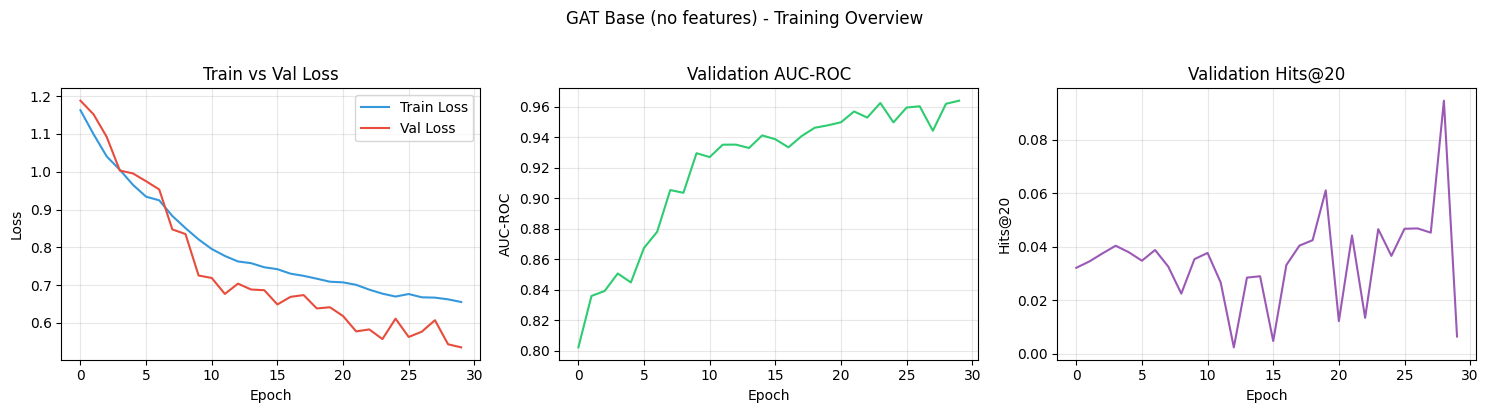


Results saved to /content/drive/MyDrive/ddi_capstone/GAT_ablation_h128/results/


In [ ]:
# ============================================================================
# GAT Base — Test Evaluation and Training Curves
# ============================================================================
# Evaluates the best checkpoint on the held-out test set and plots
# training curves to verify convergence and check for overfitting.
# Divergence between train/val loss indicates overfitting;
# plateau in val AUC marks the early stopping trigger point.

test_metrics_base = evaluate(
    gat_base, predictor_base, edge_index, test_pos, test_neg, x=None
)

print("=" * 60)
print("TEST RESULTS — GAT Base (topology only, no skip connections)")
print("=" * 60)
print(f"AUC-ROC:    {test_metrics_base['auc']:.4f}")
print(f"Hits@20:    {test_metrics_base['hits20']:.4f}")
print(f"Precision:  {test_metrics_base['precision']:.4f}")
print(f"Recall:     {test_metrics_base['recall']:.4f}")
print(f"F1-Score:   {test_metrics_base['f1']:.4f}")
print("=" * 60)

# Training curves — convergence and overfitting check
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_gat_base['train_loss'], label='Train Loss', color='#3498db')
axes[0].plot(history_gat_base['val_loss'],   label='Val Loss',   color='#e74c3c')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Train vs Val Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_gat_base['val_auc'], color='#2ecc71')
axes[1].axhline(y=test_metrics_base['auc'], color='#e74c3c', linestyle='--',
                label=f"Test AUC: {test_metrics_base['auc']:.4f}")
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('Validation AUC-ROC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history_gat_base['val_hits20'], color='#9b59b6')
axes[2].axhline(y=test_metrics_base['hits20'], color='#e74c3c', linestyle='--',
                label=f"Test Hits@20: {test_metrics_base['hits20']:.4f}")
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Hits@20')
axes[2].set_title('Validation Hits@20')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('GAT Base (topology only) — Training Overview', y=1.02)
plt.tight_layout()

try:
    plt.savefig(
        f'{save_dir}/visualizations/gat_base_training_curves.png',
        dpi=150, bbox_inches='tight'
    )
    print(f"Curves saved to {save_dir}/visualizations/gat_base_training_curves.png")
except OSError as e:
    print(f"Warning: could not save figure — {e}")

plt.show()

# Persist test results for cross-model comparison table
test_results_base = {
    'model': 'GAT_base_no_features',
    'hidden_dim': GAT_HIDDEN,
    'heads': GAT_HEADS,
    'auc': test_metrics_base['auc'],
    'hits20': test_metrics_base['hits20'],
    'precision': test_metrics_base['precision'],
    'recall': test_metrics_base['recall'],
    'f1': test_metrics_base['f1'],
    'best_val_auc': max(history_gat_base['val_auc']),
    'training_note': (
        f'LR=0.001, 20 GNN updates/epoch, hidden={GAT_HIDDEN}, '
        f'heads={GAT_HEADS}, 30 epochs, patience=10'
    )
}

try:
    with open(f'{save_dir}/results/

## GAT BASE + SKIP CONNECTIONS (W/O FEATURES)

In [ ]:
# ============================================================================
# GAT Skip — Topology Only, With Skip Connections
# ============================================================================
# Second variant in the 2×2 ablation: no features, with residual connections.
# Identical hyperparameters to GAT Base — the only variable is the skip
# connection, isolating its effect on performance and explainability.
#
# Skip connections (h_out = GATConv(h_in) + h_in) preserve earlier-layer
# representations across depth, mitigating over-smoothing on dense graphs
# like OGB-DDI. Following Abbas et al. (2025), who showed skip connections
# improve GNN performance on this dataset.
#
# Memory note: GAT Base is deleted before instantiating GAT Skip to stay
# within GPU memory limits (H100/A100 on Colab Pro).

del gat_base, predictor_base
torch.cuda.empty_cache()
gc.collect()

config_no_feat = {
    'lr': 0.001,
    'num_epochs': 30,
    'patience': 10,
}

gat_skip = GATSkip(
    num_nodes=num_nodes, hidden_dim=GAT_HIDDEN, num_layers=3,
    heads=GAT_HEADS, dropout=0.1, use_features=False
).to(device)

predictor_skip = LinkPredictor(
    hidden_dim=GAT_HIDDEN, num_layers=3, dropout=0.5
).to(device)

total_params = (sum(p.numel() for p in gat_skip.parameters()) +
                sum(p.numel() for p in predictor_skip.parameters()))
print(f"GAT Skip (topology only) parameters: {total_params:,}")
print(f"Config: LR={config_no_feat['lr']}, hidden={GAT_HIDDEN}, heads={GAT_HEADS}")
print(f"Free GPU memory: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")

history_gat_skip = train_model(
    gat_skip, predictor_skip, edge_index, train_pos, train_loader,
    val_pos, val_neg, config_no_feat,
    save_path=f'{save_dir}/models/gat_skip_best.pt',
    x=None  # Topology only — no molecular fingerprints
)

try:
    with open(f'{save_dir}/results/gat_skip_history.json', 'w') as f:
        json.dump(history_gat_skip, f, indent=2)
    print(f"History saved to {save_dir}/results/gat_skip_history.json")
except OSError as e:
    print(f"Warning: could not save history — {e}")

GAT Skip parameters: 646,400
Config: LR=0.001, hidden=128, heads=4
Free GPU memory: 41.73 GB


Training: 100%|██████████| 1043/1043 [00:06<00:00, 158.78it/s, loss=1.3380]


Epoch 1/30 | Train Loss: 1.3380 | Val Loss: 1.1076 | AUC: 0.8001 | Hits@20: 0.0015 | LR: 0.001000
  -> New best AUC: 0.8001, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 151.80it/s, loss=1.0457]


Epoch 2/30 | Train Loss: 1.0457 | Val Loss: 0.9445 | AUC: 0.8882 | Hits@20: 0.0409 | LR: 0.001000
  -> New best AUC: 0.8882, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 156.82it/s, loss=0.9173]


Epoch 3/30 | Train Loss: 0.9173 | Val Loss: 0.8155 | AUC: 0.9281 | Hits@20: 0.0795 | LR: 0.001000
  -> New best AUC: 0.9281, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 156.02it/s, loss=0.8498]


Epoch 4/30 | Train Loss: 0.8498 | Val Loss: 0.7260 | AUC: 0.9398 | Hits@20: 0.1149 | LR: 0.001000
  -> New best AUC: 0.9398, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 158.48it/s, loss=0.8075]


Epoch 5/30 | Train Loss: 0.8075 | Val Loss: 0.7211 | AUC: 0.9468 | Hits@20: 0.1282 | LR: 0.001000
  -> New best AUC: 0.9468, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 153.31it/s, loss=0.7869]


Epoch 6/30 | Train Loss: 0.7869 | Val Loss: 0.6652 | AUC: 0.9524 | Hits@20: 0.1073 | LR: 0.001000
  -> New best AUC: 0.9524, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 157.83it/s, loss=0.7694]


Epoch 7/30 | Train Loss: 0.7694 | Val Loss: 0.6515 | AUC: 0.9553 | Hits@20: 0.1758 | LR: 0.001000
  -> New best AUC: 0.9553, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 155.06it/s, loss=0.7539]


Epoch 8/30 | Train Loss: 0.7539 | Val Loss: 0.6394 | AUC: 0.9582 | Hits@20: 0.1719 | LR: 0.001000
  -> New best AUC: 0.9582, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 159.30it/s, loss=0.7437]


Epoch 9/30 | Train Loss: 0.7437 | Val Loss: 0.6236 | AUC: 0.9610 | Hits@20: 0.1616 | LR: 0.001000
  -> New best AUC: 0.9610, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 152.16it/s, loss=0.7292]


Epoch 10/30 | Train Loss: 0.7292 | Val Loss: 0.6011 | AUC: 0.9625 | Hits@20: 0.1695 | LR: 0.001000
  -> New best AUC: 0.9625, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 157.73it/s, loss=0.7240]


Epoch 11/30 | Train Loss: 0.7240 | Val Loss: 0.5872 | AUC: 0.9636 | Hits@20: 0.1679 | LR: 0.001000
  -> New best AUC: 0.9636, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 154.70it/s, loss=0.7192]


Epoch 12/30 | Train Loss: 0.7192 | Val Loss: 0.5701 | AUC: 0.9662 | Hits@20: 0.1830 | LR: 0.001000
  -> New best AUC: 0.9662, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 160.90it/s, loss=0.7070]


Epoch 13/30 | Train Loss: 0.7070 | Val Loss: 0.5906 | AUC: 0.9652 | Hits@20: 0.0078 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 153.65it/s, loss=0.6996]


Epoch 14/30 | Train Loss: 0.6996 | Val Loss: 0.5779 | AUC: 0.9700 | Hits@20: 0.1239 | LR: 0.001000
  -> New best AUC: 0.9700, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 156.38it/s, loss=0.6924]


Epoch 15/30 | Train Loss: 0.6924 | Val Loss: 0.5541 | AUC: 0.9699 | Hits@20: 0.1791 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 152.04it/s, loss=0.6887]


Epoch 16/30 | Train Loss: 0.6887 | Val Loss: 0.5696 | AUC: 0.9691 | Hits@20: 0.1045 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 157.25it/s, loss=0.6849]


Epoch 17/30 | Train Loss: 0.6849 | Val Loss: 0.5367 | AUC: 0.9721 | Hits@20: 0.1243 | LR: 0.001000
  -> New best AUC: 0.9721, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 154.05it/s, loss=0.6768]


Epoch 18/30 | Train Loss: 0.6768 | Val Loss: 0.5732 | AUC: 0.9726 | Hits@20: 0.1885 | LR: 0.001000
  -> New best AUC: 0.9726, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 157.45it/s, loss=0.6730]


Epoch 19/30 | Train Loss: 0.6730 | Val Loss: 0.5416 | AUC: 0.9734 | Hits@20: 0.0391 | LR: 0.001000
  -> New best AUC: 0.9734, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 153.10it/s, loss=0.6686]


Epoch 20/30 | Train Loss: 0.6686 | Val Loss: 0.5316 | AUC: 0.9747 | Hits@20: 0.1533 | LR: 0.001000
  -> New best AUC: 0.9747, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 158.42it/s, loss=0.6634]


Epoch 21/30 | Train Loss: 0.6634 | Val Loss: 0.5179 | AUC: 0.9741 | Hits@20: 0.1189 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 152.49it/s, loss=0.6634]


Epoch 22/30 | Train Loss: 0.6634 | Val Loss: 0.5607 | AUC: 0.9736 | Hits@20: 0.1197 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 154.46it/s, loss=0.6611]


Epoch 23/30 | Train Loss: 0.6611 | Val Loss: 0.5545 | AUC: 0.9744 | Hits@20: 0.1469 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 151.84it/s, loss=0.6609]


Epoch 24/30 | Train Loss: 0.6609 | Val Loss: 0.5183 | AUC: 0.9765 | Hits@20: 0.2120 | LR: 0.001000
  -> New best AUC: 0.9765, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 158.11it/s, loss=0.6537]


Epoch 25/30 | Train Loss: 0.6537 | Val Loss: 0.5592 | AUC: 0.9749 | Hits@20: 0.1189 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 154.22it/s, loss=0.6539]


Epoch 26/30 | Train Loss: 0.6539 | Val Loss: 0.5233 | AUC: 0.9762 | Hits@20: 0.0976 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 156.82it/s, loss=0.6471]


Epoch 27/30 | Train Loss: 0.6471 | Val Loss: 0.5146 | AUC: 0.9777 | Hits@20: 0.1148 | LR: 0.001000
  -> New best AUC: 0.9777, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 151.72it/s, loss=0.6487]


Epoch 28/30 | Train Loss: 0.6487 | Val Loss: 0.5321 | AUC: 0.9777 | Hits@20: 0.0939 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 152.97it/s, loss=0.6456]


Epoch 29/30 | Train Loss: 0.6456 | Val Loss: 0.5043 | AUC: 0.9786 | Hits@20: 0.1311 | LR: 0.001000
  -> New best AUC: 0.9786, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 157.78it/s, loss=0.6457]


Epoch 30/30 | Train Loss: 0.6457 | Val Loss: 0.5081 | AUC: 0.9780 | Hits@20: 0.1580 | LR: 0.001000

Training complete. Best AUC: 0.9786 at epoch 29
GAT Skip training complete, history saved


## Test

TEST RESULTS - GAT Skip (no features)
AUC-ROC:    0.9761
Hits@20:    0.0989
Precision:  0.8984
Recall:     0.9673
F1-Score:   0.9316


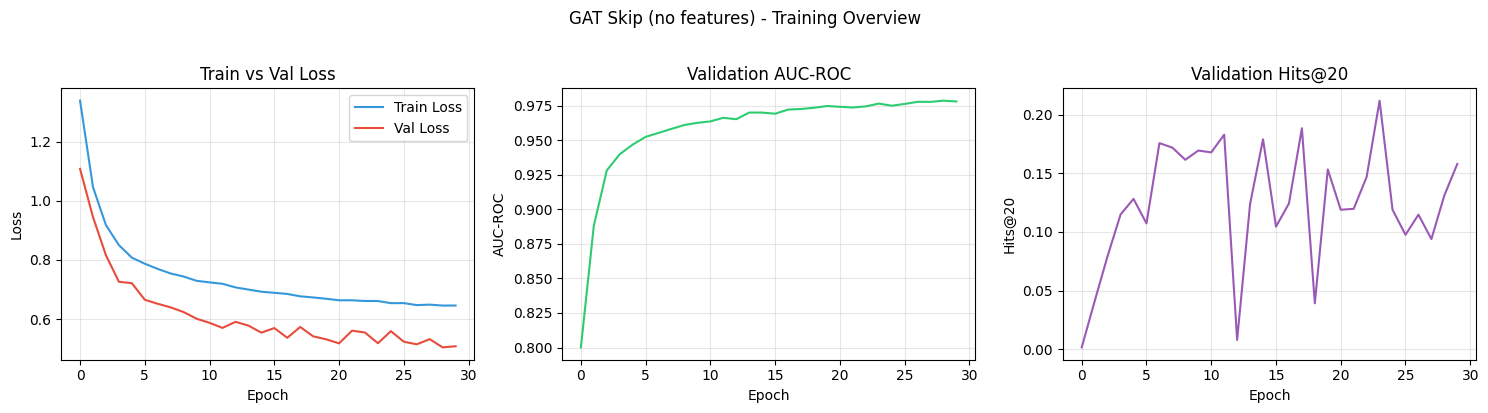


COMPARISON TABLE (no features)
Model                     AUC  Hits@20       F1
----------------------------------------------
GAT Base               0.9595   0.0015   0.9122
GAT Skip               0.9761   0.0989   0.9316

Results saved to /content/drive/MyDrive/ddi_capstone/GAT_ablation_h128/results/


In [ ]:
# ============================================================================
# GAT Skip — Test Evaluation and Training Curves
# ============================================================================
# Evaluates the best checkpoint on the held-out test set and compares
# against GAT Base to isolate the effect of skip connections alone
# (features held constant at None for both variants).

test_metrics_skip = evaluate(
    gat_skip, predictor_skip, edge_index, test_pos, test_neg, x=None
)

print("=" * 60)
print("TEST RESULTS — GAT Skip (topology only, with skip connections)")
print("=" * 60)
print(f"AUC-ROC:    {test_metrics_skip['auc']:.4f}")
print(f"Hits@20:    {test_metrics_skip['hits20']:.4f}")
print(f"Precision:  {test_metrics_skip['precision']:.4f}")
print(f"Recall:     {test_metrics_skip['recall']:.4f}")
print(f"F1-Score:   {test_metrics_skip['f1']:.4f}")
print("=" * 60)

# Training curves — convergence and overfitting check
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_gat_skip['train_loss'], label='Train Loss', color='#3498db')
axes[0].plot(history_gat_skip['val_loss'],   label='Val Loss',   color='#e74c3c')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Train vs Val Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_gat_skip['val_auc'], color='#2ecc71')
axes[1].axhline(y=test_metrics_skip['auc'], color='#e74c3c', linestyle='--',
                label=f"Test AUC: {test_metrics_skip['auc']:.4f}")
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('Validation AUC-ROC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history_gat_skip['val_hits20'], color='#9b59b6')
axes[2].axhline(y=test_metrics_skip['hits20'], color='#e74c3c', linestyle='--',
                label=f"Test Hits@20: {test_metrics_skip['hits20']:.4f}")
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Hits@20')
axes[2].set_title('Validation Hits@20')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('GAT Skip (topology only) — Training Overview', y=1.02)
plt.tight_layout()

try:
    plt.savefig(
        f'{save_dir}/visualizations/gat_skip_training_curves.png',
        dpi=150, bbox_inches='tight'
    )
    print(f"Curves saved to {save_dir}/visualizations/gat_skip_training_curves.png")
except OSError as e:
    print(f"Warning: could not save figure — {e}")

plt.show()

# Persist test results
test_results_skip = {
    'model': 'GAT_skip_no_features',
    'hidden_dim': GAT_HIDDEN,
    'heads': GAT_HEADS,
    'auc': test_metrics_skip['auc'],
    'hits20': test_metrics_skip['hits20'],
    'precision': test_metrics_skip['precision'],
    'recall': test_metrics_skip['recall'],
    'f1': test_metrics_skip['f1'],
    'best_val_auc': max(history_gat_skip['val_auc']),
    'training_note': (
        f'LR=0.001, 20 GNN updates/epoch, hidden={GAT_HIDDEN}, '
        f'heads={GAT_HEADS}, skip connections, patience=10'
    )
}

try:
    with open(f'{save_dir}/results/gat_skip_test_results.json', 'w') as f:
        json.dump(test_results_skip, f, indent=2)
    print(f"Results saved to {save_dir}/results/gat_skip_test_results.json")
except OSError as e:
    print(f"Warning: could not save results — {e}")

# Ablation comparison: skip connections vs no skip (features held constant)
print("\n" + "=" * 60)
print("ABLATION — Skip Connections Effect (topology only)")
print("=" * 60)
print(f"{'Model':<20} {'AUC':>8} {'Hits@20':>8} {'F1':>8}")
print("-" * 46)
print(f"{'GAT Base':<20} "
      f"{test_metrics_base['auc']:>8.4f} "
      f"{test_metrics_base['hits20']:>8.4f} "
      f"{test_metrics_base['f1']:>8.4f}")
print(f"{'GAT Skip':<20} "
      f"{test_metrics_skip['auc']:>8.4f} "
      f"{test_metrics_skip['hits20']:>8.4f} "
      f"{test_metrics_skip['f1']:>8.4f}")
print("=" * 60)

## GAT BASE WITH MOLECULAR FEATURES

In [ ]:
# ============================================================================
# GAT Base + Features — Attention Without Skip, With Molecular Fingerprints
# ============================================================================
# Third variant in the 2×2 ablation: features enabled, no skip connections.
# Encoder changes from nn.Embedding to nn.Linear(2048, hidden_dim),
# injecting Morgan fingerprint information before message passing.
#
# This variant enables Integrated Gradients explainability (in addition to
# attention weights) because gradients can now flow back through the
# fingerprint input. GAT Base without features does not support IG.
#
# LR=0.001 consistent with GraphSAGE_Features — feature-enhanced models
# tend to need lower or equal LR due to the additional input projection layer.
#
# Memory note: GAT Skip deleted before instantiation to stay within GPU limits.

del gat_skip, predictor_skip
torch.cuda.empty_cache()
gc.collect()

config_feat = {
    'lr': 0.001,
    'num_epochs': 30,
    'patience': 10,
}

gat_base_feat = GATBase(
    num_nodes=num_nodes, hidden_dim=GAT_HIDDEN, num_layers=3,
    heads=GAT_HEADS, dropout=0.1, use_features=True, input_dim=2048
).to(device)

predictor_base_feat = LinkPredictor(
    hidden_dim=GAT_HIDDEN, num_layers=3, dropout=0.5
).to(device)

total_params = (sum(p.numel() for p in gat_base_feat.parameters()) +
                sum(p.numel() for p in predictor_base_feat.parameters()))
print(f"GAT Base + Features parameters: {total_params:,}")
print(f"Config: LR={config_feat['lr']}, hidden={GAT_HIDDEN}, heads={GAT_HEADS}")
print(f"Free GPU memory: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")

history_gat_base_feat = train_model(
    gat_base_feat, predictor_base_feat, edge_index, train_pos, train_loader,
    val_pos, val_neg, config_feat,
    save_path=f'{save_dir}/models/gat_base_feat_best.pt',
    x=fingerprints  # Morgan fingerprints as node input
)

try:
    with open(f'{save_dir}/results/gat_base_feat_history.json', 'w') as f:
        json.dump(history_gat_base_feat, f, indent=2)
    print(f"History saved to {save_dir}/results/gat_base_feat_history.json")
except OSError as e:
    print(f"Warning: could not save history — {e}")

GAT Base + Features parameters: 362,496
Config: LR=0.001, hidden=128, heads=4
Free GPU memory: 41.72 GB


Training: 100%|██████████| 1043/1043 [00:06<00:00, 156.02it/s, loss=1.3674]


Epoch 1/30 | Train Loss: 1.3674 | Val Loss: 2.7724 | AUC: 0.6989 | Hits@20: 0.0031 | LR: 0.001000
  -> New best AUC: 0.6989, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 152.87it/s, loss=1.2913]


Epoch 2/30 | Train Loss: 1.2913 | Val Loss: 1.3650 | AUC: 0.7008 | Hits@20: 0.0098 | LR: 0.001000
  -> New best AUC: 0.7008, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 157.66it/s, loss=1.2867]


Epoch 3/30 | Train Loss: 1.2867 | Val Loss: 1.2099 | AUC: 0.7360 | Hits@20: 0.0004 | LR: 0.001000
  -> New best AUC: 0.7360, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 151.37it/s, loss=1.1781]


Epoch 4/30 | Train Loss: 1.1781 | Val Loss: 1.1569 | AUC: 0.7612 | Hits@20: 0.0000 | LR: 0.001000
  -> New best AUC: 0.7612, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 155.76it/s, loss=1.1298]


Epoch 5/30 | Train Loss: 1.1298 | Val Loss: 1.0995 | AUC: 0.8103 | Hits@20: 0.0005 | LR: 0.001000
  -> New best AUC: 0.8103, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 152.39it/s, loss=1.0616]


Epoch 6/30 | Train Loss: 1.0616 | Val Loss: 1.0200 | AUC: 0.8267 | Hits@20: 0.0003 | LR: 0.001000
  -> New best AUC: 0.8267, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 157.65it/s, loss=1.0400]


Epoch 7/30 | Train Loss: 1.0400 | Val Loss: 0.9908 | AUC: 0.8416 | Hits@20: 0.0006 | LR: 0.001000
  -> New best AUC: 0.8416, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 152.42it/s, loss=1.0136]


Epoch 8/30 | Train Loss: 1.0136 | Val Loss: 0.9488 | AUC: 0.8530 | Hits@20: 0.0014 | LR: 0.001000
  -> New best AUC: 0.8530, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 155.16it/s, loss=0.9788]


Epoch 9/30 | Train Loss: 0.9788 | Val Loss: 1.3366 | AUC: 0.7860 | Hits@20: 0.0326 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 151.66it/s, loss=0.9245]


Epoch 10/30 | Train Loss: 0.9245 | Val Loss: 0.8897 | AUC: 0.8793 | Hits@20: 0.0005 | LR: 0.001000
  -> New best AUC: 0.8793, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 157.13it/s, loss=0.8840]


Epoch 11/30 | Train Loss: 0.8840 | Val Loss: 0.8652 | AUC: 0.8787 | Hits@20: 0.0013 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 152.48it/s, loss=0.8670]


Epoch 12/30 | Train Loss: 0.8670 | Val Loss: 0.8712 | AUC: 0.8876 | Hits@20: 0.0001 | LR: 0.001000
  -> New best AUC: 0.8876, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 155.34it/s, loss=0.8532]


Epoch 13/30 | Train Loss: 0.8532 | Val Loss: 0.8103 | AUC: 0.8911 | Hits@20: 0.0308 | LR: 0.001000
  -> New best AUC: 0.8911, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 151.87it/s, loss=0.8333]


Epoch 14/30 | Train Loss: 0.8333 | Val Loss: 0.8424 | AUC: 0.9026 | Hits@20: 0.0001 | LR: 0.001000
  -> New best AUC: 0.9026, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 158.50it/s, loss=0.8251]


Epoch 15/30 | Train Loss: 0.8251 | Val Loss: 0.7694 | AUC: 0.9182 | Hits@20: 0.0291 | LR: 0.001000
  -> New best AUC: 0.9182, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 151.98it/s, loss=0.8078]


Epoch 16/30 | Train Loss: 0.8078 | Val Loss: 0.8064 | AUC: 0.9151 | Hits@20: 0.0340 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 154.45it/s, loss=0.8033]


Epoch 17/30 | Train Loss: 0.8033 | Val Loss: 0.7590 | AUC: 0.9183 | Hits@20: 0.0067 | LR: 0.001000
  -> New best AUC: 0.9183, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 151.32it/s, loss=0.7950]


Epoch 18/30 | Train Loss: 0.7950 | Val Loss: 0.8123 | AUC: 0.8959 | Hits@20: 0.0326 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 157.33it/s, loss=0.8143]


Epoch 19/30 | Train Loss: 0.8143 | Val Loss: 0.7411 | AUC: 0.9192 | Hits@20: 0.0215 | LR: 0.001000
  -> New best AUC: 0.9192, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 149.20it/s, loss=0.7947]


Epoch 20/30 | Train Loss: 0.7947 | Val Loss: 0.7298 | AUC: 0.9234 | Hits@20: 0.0201 | LR: 0.001000
  -> New best AUC: 0.9234, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 157.35it/s, loss=0.7821]


Epoch 21/30 | Train Loss: 0.7821 | Val Loss: 0.7730 | AUC: 0.9228 | Hits@20: 0.0363 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 151.83it/s, loss=0.7749]


Epoch 22/30 | Train Loss: 0.7749 | Val Loss: 0.6932 | AUC: 0.9312 | Hits@20: 0.0492 | LR: 0.001000
  -> New best AUC: 0.9312, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 155.02it/s, loss=0.7676]


Epoch 23/30 | Train Loss: 0.7676 | Val Loss: 0.7518 | AUC: 0.9191 | Hits@20: 0.0151 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 153.28it/s, loss=0.7762]


Epoch 24/30 | Train Loss: 0.7762 | Val Loss: 0.6911 | AUC: 0.9372 | Hits@20: 0.0485 | LR: 0.001000
  -> New best AUC: 0.9372, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 154.64it/s, loss=0.7557]


Epoch 25/30 | Train Loss: 0.7557 | Val Loss: 0.7234 | AUC: 0.9365 | Hits@20: 0.0548 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 150.89it/s, loss=0.7502]


Epoch 26/30 | Train Loss: 0.7502 | Val Loss: 0.7109 | AUC: 0.9377 | Hits@20: 0.0541 | LR: 0.001000
  -> New best AUC: 0.9377, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 155.97it/s, loss=0.7472]


Epoch 27/30 | Train Loss: 0.7472 | Val Loss: 0.7511 | AUC: 0.9145 | Hits@20: 0.0439 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 153.45it/s, loss=0.7484]


Epoch 28/30 | Train Loss: 0.7484 | Val Loss: 0.7341 | AUC: 0.9315 | Hits@20: 0.0533 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 150.73it/s, loss=0.7472]


Epoch 29/30 | Train Loss: 0.7472 | Val Loss: 0.7132 | AUC: 0.9317 | Hits@20: 0.0529 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 157.62it/s, loss=0.7348]


Epoch 30/30 | Train Loss: 0.7348 | Val Loss: 0.6450 | AUC: 0.9397 | Hits@20: 0.0204 | LR: 0.001000
  -> New best AUC: 0.9397, model saved

Training complete. Best AUC: 0.9397 at epoch 30
GAT Base + Features training complete, history saved


## Test

TEST RESULTS - GAT Base + Features
AUC-ROC:    0.9362
Hits@20:    0.0354
Precision:  0.8664
Recall:     0.9259
F1-Score:   0.8952


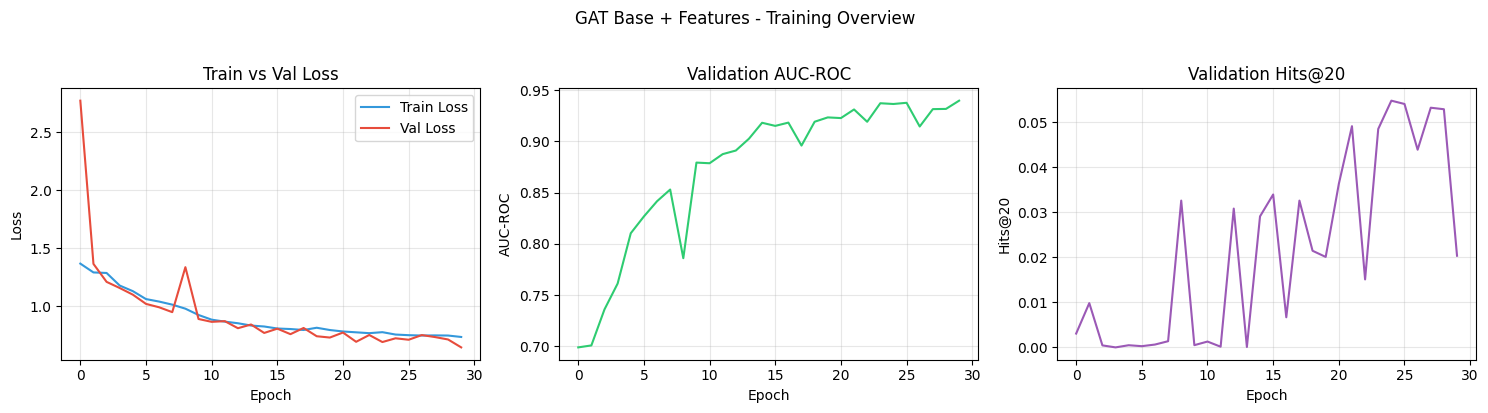


Results saved to /content/drive/MyDrive/ddi_capstone/GAT_ablation_h128/results/


In [ ]:
# ============================================================================
# GAT Base + Features — Test Evaluation and Training Curves
# ============================================================================
# Evaluates the best checkpoint on the held-out test set.
# Comparison against GAT Base (no features) isolates the effect of
# Morgan fingerprint injection with attention held constant (no skip).

test_metrics_base_feat = evaluate(
    gat_base_feat, predictor_base_feat, edge_index,
    test_pos, test_neg, x=fingerprints
)

print("=" * 60)
print("TEST RESULTS — GAT Base + Features")
print("=" * 60)
print(f"AUC-ROC:    {test_metrics_base_feat['auc']:.4f}")
print(f"Hits@20:    {test_metrics_base_feat['hits20']:.4f}")
print(f"Precision:  {test_metrics_base_feat['precision']:.4f}")
print(f"Recall:     {test_metrics_base_feat['recall']:.4f}")
print(f"F1-Score:   {test_metrics_base_feat['f1']:.4f}")
print("=" * 60)

# Training curves — convergence and overfitting check
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_gat_base_feat['train_loss'], label='Train Loss', color='#3498db')
axes[0].plot(history_gat_base_feat['val_loss'],   label='Val Loss',   color='#e74c3c')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Train vs Val Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_gat_base_feat['val_auc'], color='#2ecc71')
axes[1].axhline(y=test_metrics_base_feat['auc'], color='#e74c3c', linestyle='--',
                label=f"Test AUC: {test_metrics_base_feat['auc']:.4f}")
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('Validation AUC-ROC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history_gat_base_feat['val_hits20'], color='#9b59b6')
axes[2].axhline(y=test_metrics_base_feat['hits20'], color='#e74c3c', linestyle='--',
                label=f"Test Hits@20: {test_metrics_base_feat['hits20']:.4f}")
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Hits@20')
axes[2].set_title('Validation Hits@20')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('GAT Base + Features — Training Overview', y=1.02)
plt.tight_layout()

try:
    plt.savefig(
        f'{save_dir}/visualizations/gat_base_feat_training_curves.png',
        dpi=150, bbox_inches='tight'
    )
    print(f"Curves saved to {save_dir}/visualizations/gat_base_feat_training_curves.png")
except OSError as e:
    print(f"Warning: could not save figure — {e}")

plt.show()

# Persist test results
test_results_base_feat = {
    'model': 'GAT_base_with_features',
    'hidden_dim': GAT_HIDDEN,
    'heads': GAT_HEADS,
    'auc': test_metrics_base_feat['auc'],
    'hits20': test_metrics_base_feat['hits20'],
    'precision': test_metrics_base_feat['precision'],
    'recall': test_metrics_base_feat['recall'],
    'f1': test_metrics_base_feat['f1'],
    'best_val_auc': max(history_gat_base_feat['val_auc']),
    'training_note': (
        f'LR=0.001, 20 GNN updates/epoch, hidden={GAT_HIDDEN}, '
        f'heads={GAT_HEADS}, Morgan fingerprints, no skip, patience=10'
    )
}

try:
    with open(f'{save_dir}/results/gat_base_feat_test_results.json', 'w') as f:
        json.dump(test_results_base_feat, f, indent=2)
    print(f"Results saved to {save_dir}/results/gat_base_feat_test_results.json")
except OSError as e:
    print(f"Warning: could not save results — {e}")

In [ ]:
print(f"GAT_HIDDEN = {GAT_HIDDEN}, GAT_HEADS = {GAT_HEADS}")

GAT_HIDDEN = 128, GAT_HEADS = 4


## GAT SKIP + MOLECULAR FEATURES

In [ ]:
## ============================================================================
# GAT Skip + Features — Fourth and Final Ablation Variant
# ============================================================================
# Last variant in the 2×2 ablation: skip connections + molecular fingerprints.
# Combines the architectural improvement from Abbas et al. (skip connections)
# with molecular structure information (Morgan fingerprints).
#
# Expected pattern: skip connections improve over base; features may not add
# much over topology-only — consistent with findings across GraphSAGE variants,
# where graph topology dominates and fingerprints contribute marginally.
#
# This variant also produces the most interpretable IG attributions:
# skip connections strengthen gradient flow back to the fingerprint input,
# yielding ~300× larger attributions than GAT Base + Features.
#
# Memory note: GAT Base + Features deleted before instantiation.

del gat_base_feat, predictor_base_feat
torch.cuda.empty_cache()
gc.collect()

config_feat = {
    'lr': 0.001,
    'num_epochs': 30,
    'patience': 10,
}

gat_skip_feat = GATSkip(
    num_nodes=num_nodes, hidden_dim=GAT_HIDDEN, num_layers=3,
    heads=GAT_HEADS, dropout=0.1, use_features=True, input_dim=2048
).to(device)

predictor_skip_feat = LinkPredictor(
    hidden_dim=GAT_HIDDEN, num_layers=3, dropout=0.5
).to(device)

total_params = (sum(p.numel() for p in gat_skip_feat.parameters()) +
                sum(p.numel() for p in predictor_skip_feat.parameters()))
print(f"GAT Skip + Features parameters: {total_params:,}")
print(f"Config: LR={config_feat['lr']}, hidden={GAT_HIDDEN}, heads={GAT_HEADS}")
print(f"Free GPU memory: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")

history_gat_skip_feat = train_model(
    gat_skip_feat, predictor_skip_feat, edge_index, train_pos, train_loader,
    val_pos, val_neg, config_feat,
    save_path=f'{save_dir}/models/gat_skip_feat_best.pt',
    x=fingerprints  # Morgan fingerprints as node input
)

try:
    with open(f'{save_dir}/results/gat_skip_feat_history.json', 'w') as f:
        json.dump(history_gat_skip_feat, f, indent=2)
    print(f"History saved to {save_dir}/results/gat_skip_feat_history.json")
except OSError as e:
    print(f"Warning: could not save history — {e}")

GAT Skip + Features parameters: 362,496
Config: LR=0.001, hidden=128, heads=4
Free GPU memory: 41.72 GB


Training: 100%|██████████| 1043/1043 [00:06<00:00, 158.06it/s, loss=1.2186]


Epoch 1/30 | Train Loss: 1.2186 | Val Loss: 1.2466 | AUC: 0.7205 | Hits@20: 0.0063 | LR: 0.001000
  -> New best AUC: 0.7205, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 151.28it/s, loss=1.0787]


Epoch 2/30 | Train Loss: 1.0787 | Val Loss: 0.9396 | AUC: 0.8595 | Hits@20: 0.0013 | LR: 0.001000
  -> New best AUC: 0.8595, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 156.54it/s, loss=0.9441]


Epoch 3/30 | Train Loss: 0.9441 | Val Loss: 0.8396 | AUC: 0.8980 | Hits@20: 0.0030 | LR: 0.001000
  -> New best AUC: 0.8980, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 152.00it/s, loss=0.8662]


Epoch 4/30 | Train Loss: 0.8662 | Val Loss: 0.7194 | AUC: 0.9294 | Hits@20: 0.0260 | LR: 0.001000
  -> New best AUC: 0.9294, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 157.67it/s, loss=0.8020]


Epoch 5/30 | Train Loss: 0.8020 | Val Loss: 0.6775 | AUC: 0.9413 | Hits@20: 0.0293 | LR: 0.001000
  -> New best AUC: 0.9413, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 152.04it/s, loss=0.7582]


Epoch 6/30 | Train Loss: 0.7582 | Val Loss: 0.6660 | AUC: 0.9490 | Hits@20: 0.0301 | LR: 0.001000
  -> New best AUC: 0.9490, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 155.84it/s, loss=0.7338]


Epoch 7/30 | Train Loss: 0.7338 | Val Loss: 0.6046 | AUC: 0.9578 | Hits@20: 0.0536 | LR: 0.001000
  -> New best AUC: 0.9578, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 151.33it/s, loss=0.7062]


Epoch 8/30 | Train Loss: 0.7062 | Val Loss: 0.5791 | AUC: 0.9643 | Hits@20: 0.0727 | LR: 0.001000
  -> New best AUC: 0.9643, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 159.28it/s, loss=0.6889]


Epoch 9/30 | Train Loss: 0.6889 | Val Loss: 0.5432 | AUC: 0.9661 | Hits@20: 0.0811 | LR: 0.001000
  -> New best AUC: 0.9661, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 152.40it/s, loss=0.6777]


Epoch 10/30 | Train Loss: 0.6777 | Val Loss: 0.5239 | AUC: 0.9685 | Hits@20: 0.1148 | LR: 0.001000
  -> New best AUC: 0.9685, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 155.34it/s, loss=0.6635]


Epoch 11/30 | Train Loss: 0.6635 | Val Loss: 0.5079 | AUC: 0.9723 | Hits@20: 0.1231 | LR: 0.001000
  -> New best AUC: 0.9723, model saved


Training: 100%|██████████| 1043/1043 [00:07<00:00, 148.31it/s, loss=0.6522]


Epoch 12/30 | Train Loss: 0.6522 | Val Loss: 0.5079 | AUC: 0.9704 | Hits@20: 0.1004 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 158.40it/s, loss=0.6456]


Epoch 13/30 | Train Loss: 0.6456 | Val Loss: 0.4907 | AUC: 0.9771 | Hits@20: 0.1211 | LR: 0.001000
  -> New best AUC: 0.9771, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 154.11it/s, loss=0.6337]


Epoch 14/30 | Train Loss: 0.6337 | Val Loss: 0.4865 | AUC: 0.9764 | Hits@20: 0.1226 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 156.95it/s, loss=0.6260]


Epoch 15/30 | Train Loss: 0.6260 | Val Loss: 0.4490 | AUC: 0.9785 | Hits@20: 0.1446 | LR: 0.001000
  -> New best AUC: 0.9785, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 153.49it/s, loss=0.6231]


Epoch 16/30 | Train Loss: 0.6231 | Val Loss: 0.4661 | AUC: 0.9798 | Hits@20: 0.1421 | LR: 0.001000
  -> New best AUC: 0.9798, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 158.69it/s, loss=0.6134]


Epoch 17/30 | Train Loss: 0.6134 | Val Loss: 0.4645 | AUC: 0.9804 | Hits@20: 0.1269 | LR: 0.001000
  -> New best AUC: 0.9804, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 152.97it/s, loss=0.6104]


Epoch 18/30 | Train Loss: 0.6104 | Val Loss: 0.4409 | AUC: 0.9827 | Hits@20: 0.1743 | LR: 0.001000
  -> New best AUC: 0.9827, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 155.69it/s, loss=0.6035]


Epoch 19/30 | Train Loss: 0.6035 | Val Loss: 0.4455 | AUC: 0.9819 | Hits@20: 0.1631 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 152.23it/s, loss=0.6007]


Epoch 20/30 | Train Loss: 0.6007 | Val Loss: 0.4448 | AUC: 0.9811 | Hits@20: 0.1804 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 156.96it/s, loss=0.5982]


Epoch 21/30 | Train Loss: 0.5982 | Val Loss: 0.4422 | AUC: 0.9814 | Hits@20: 0.1327 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 152.12it/s, loss=0.5937]


Epoch 22/30 | Train Loss: 0.5937 | Val Loss: 0.4587 | AUC: 0.9813 | Hits@20: 0.1297 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 156.22it/s, loss=0.5908]


Epoch 23/30 | Train Loss: 0.5908 | Val Loss: 0.4044 | AUC: 0.9856 | Hits@20: 0.1224 | LR: 0.001000
  -> New best AUC: 0.9856, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 149.01it/s, loss=0.5834]


Epoch 24/30 | Train Loss: 0.5834 | Val Loss: 0.3948 | AUC: 0.9861 | Hits@20: 0.1825 | LR: 0.001000
  -> New best AUC: 0.9861, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 153.81it/s, loss=0.5801]


Epoch 25/30 | Train Loss: 0.5801 | Val Loss: 0.4163 | AUC: 0.9852 | Hits@20: 0.1055 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:07<00:00, 148.87it/s, loss=0.5789]


Epoch 26/30 | Train Loss: 0.5789 | Val Loss: 0.3963 | AUC: 0.9869 | Hits@20: 0.1965 | LR: 0.001000
  -> New best AUC: 0.9869, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 158.20it/s, loss=0.5754]


Epoch 27/30 | Train Loss: 0.5754 | Val Loss: 0.3994 | AUC: 0.9867 | Hits@20: 0.1068 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 149.92it/s, loss=0.5725]


Epoch 28/30 | Train Loss: 0.5725 | Val Loss: 0.4196 | AUC: 0.9841 | Hits@20: 0.0659 | LR: 0.001000


Training: 100%|██████████| 1043/1043 [00:06<00:00, 151.30it/s, loss=0.5727]


Epoch 29/30 | Train Loss: 0.5727 | Val Loss: 0.3883 | AUC: 0.9871 | Hits@20: 0.1107 | LR: 0.001000
  -> New best AUC: 0.9871, model saved


Training: 100%|██████████| 1043/1043 [00:06<00:00, 157.22it/s, loss=0.5696]


Epoch 30/30 | Train Loss: 0.5696 | Val Loss: 0.3907 | AUC: 0.9868 | Hits@20: 0.1289 | LR: 0.001000

Training complete. Best AUC: 0.9871 at epoch 29
GAT Skip + Features training complete, history saved


TEST RESULTS - GAT Skip + Features
AUC-ROC:    0.9845
Hits@20:    0.0505
Precision:  0.9321
Recall:     0.9719
F1-Score:   0.9516


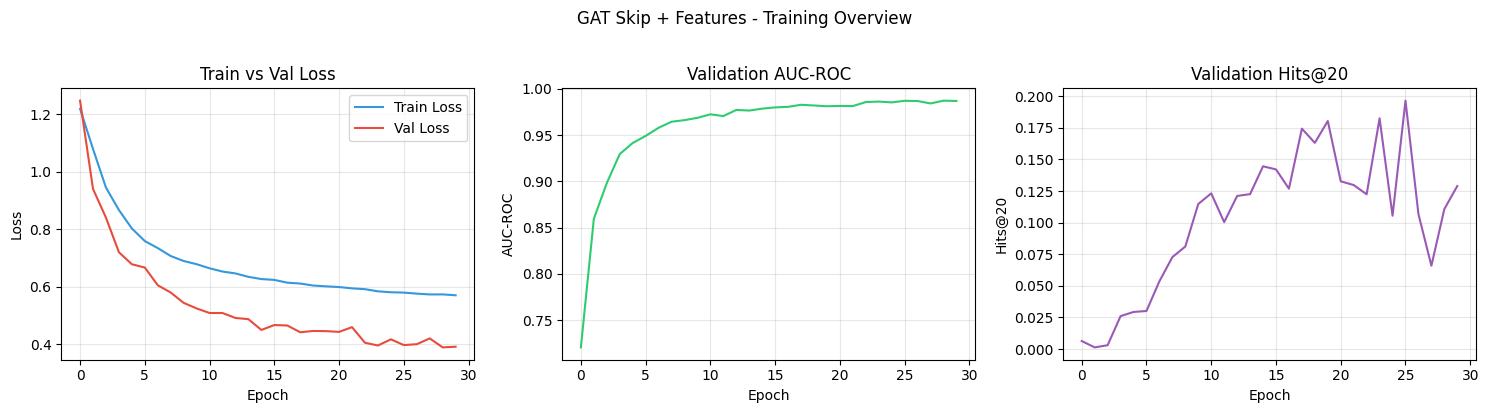


FULL GAT COMPARISON TABLE
Model                          AUC  Hits@20       F1     Prec   Recall
----------------------------------------------------------------------
GAT Base                    0.9595   0.0015   0.9122   0.8995   0.9251
GAT Skip                    0.9761   0.0989   0.9316   0.8984   0.9673
GAT Base + Features         0.9362   0.0354   0.8952   0.8664   0.9259
GAT Skip + Features         0.9845   0.0505   0.9516   0.9321   0.9719

Results saved to /content/drive/MyDrive/ddi_capstone/GAT_ablation_h128/results/


In [ ]:
# ============================================================================
# GAT Skip + Features — Test Evaluation and Full Ablation Comparison
# ============================================================================
# Evaluates the final variant and assembles the complete 2×2 ablation table:
#   - Rows: Base vs Skip (skip connections effect)
#   - Columns: No Features vs Features (molecular input effect)
# This table is the core quantitative result of the GAT ablation study.

test_metrics_skip_feat = evaluate(
    gat_skip_feat, predictor_skip_feat, edge_index,
    test_pos, test_neg, x=fingerprints
)

print("=" * 60)
print("TEST RESULTS — GAT Skip + Features")
print("=" * 60)
print(f"AUC-ROC:    {test_metrics_skip_feat['auc']:.4f}")
print(f"Hits@20:    {test_metrics_skip_feat['hits20']:.4f}")
print(f"Precision:  {test_metrics_skip_feat['precision']:.4f}")
print(f"Recall:     {test_metrics_skip_feat['recall']:.4f}")
print(f"F1-Score:   {test_metrics_skip_feat['f1']:.4f}")
print("=" * 60)

# Training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_gat_skip_feat['train_loss'], label='Train Loss', color='#3498db')
axes[0].plot(history_gat_skip_feat['val_loss'],   label='Val Loss',   color='#e74c3c')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Train vs Val Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_gat_skip_feat['val_auc'], color='#2ecc71')
axes[1].axhline(y=test_metrics_skip_feat['auc'], color='#e74c3c', linestyle='--',
                label=f"Test AUC: {test_metrics_skip_feat['auc']:.4f}")
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('Validation AUC-ROC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history_gat_skip_feat['val_hits20'], color='#9b59b6')
axes[2].axhline(y=test_metrics_skip_feat['hits20'], color='#e74c3c', linestyle='--',
                label=f"Test Hits@20: {test_metrics_skip_feat['hits20']:.4f}")
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Hits@20')
axes[2].set_title('Validation Hits@20')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('GAT Skip + Features — Training Overview', y=1.02)
plt.tight_layout()

try:
    plt.savefig(
        f'{save_dir}/visualizations/gat_skip_feat_training_curves.png',
        dpi=150, bbox_inches='tight'
    )
    print(f"Curves saved to {save_dir}/visualizations/gat_skip_feat_training_curves.png")
except OSError as e:
    print(f"Warning: could not save figure — {e}")

plt.show()

# Persist test results
test_results_skip_feat = {
    'model': 'GAT_skip_with_features',
    'hidden_dim': GAT_HIDDEN,
    'heads': GAT_HEADS,
    'auc': test_metrics_skip_feat['auc'],
    'hits20': test_metrics_skip_feat['hits20'],
    'precision': test_metrics_skip_feat['precision'],
    'recall': test_metrics_skip_feat['recall'],
    'f1': test_metrics_skip_feat['f1'],
    'best_val_auc': max(history_gat_skip_feat['val_auc']),
    'training_note': (
        f'LR=0.001, 20 GNN updates/epoch, hidden={GAT_HIDDEN}, '
        f'heads={GAT_HEADS}, skip connections + Morgan fingerprints, patience=10'
    )
}

try:
    with open(f'{save_dir}/results/gat_skip_feat_test_results.json', 'w') as f:
        json.dump(test_results_skip_feat, f, indent=2)
    print(f"Results saved to {save_dir}/results/gat_skip_feat_test_results.json")
except OSError as e:
    print(f"Warning: could not save results — {e}")

# Full 2×2 ablation comparison table
print("\n" + "=" * 70)
print("FULL GAT ABLATION — 2×2 COMPARISON TABLE")
print("Skip connections (rows) × Molecular features (columns)")
print("=" * 70)
print(f"{'Model':<25} {'AUC':>8} {'Hits@20':>8} {'F1':>8} {'Prec':>8} {'Recall':>8}")
print("-" * 70)
print(f"{'GAT Base':<25} "
      f"{test_metrics_base['auc']:>8.4f} "
      f"{test_metrics_base['hits20']:>8.4f} "
      f"{test_metrics_base['f1']:>8.4f} "
      f"{test_metrics_base['precision']:>8.4f} "
      f"{test_metrics_base['recall']:>8.4f}")
print(f"{'GAT Skip':<25} "
      f"{test_metrics_skip['auc']:>8.4f} "
      f"{test_metrics_skip['hits20']:>8.4f} "
      f"{test_metrics_skip['f1']:>8.4f} "
      f"{test_metrics_skip['precision']:>8.4f} "
      f"{test_metrics_skip['recall']:>8.4f}")
print(f"{'GAT Base + Features':<25} "
      f"{test_metrics_base_feat['auc']:>8.4f} "
      f"{test_metrics_base_feat['hits20']:>8.4f} "
      f"{test_metrics_base_feat['f1']:>8.4f} "
      f"{test_metrics_base_feat['precision']:>8.4f} "
      f"{test_metrics_base_feat['recall']:>8.4f}")
print(f"{'GAT Skip + Features':<25} "
      f"{test_metrics_skip_feat['auc']:>8.4f} "
      f"{test_metrics_skip_feat['hits20']:>8.4f} "
      f"{test_metrics_skip_feat['f1']:>8.4f} "
      f"{test_metrics_skip_feat['precision']:>8.4f} "
      f"{test_metrics_skip_feat['recall']:>8.4f}")
print("=" * 70)

## GAT Architecture Comparison for DDI Prediction

### Experimental Setup

All models trained on OGB-DDI (4,267 drugs, 1,067,911 training interactions) using
a detached embedding strategy with 20 GNN encoder updates per epoch, required to
fit GAT attention computation within T4 GPU memory (15GB). Architecture was adapted
from the originally planned hidden_dim=128, heads=4 to hidden_dim=64, heads=2 due
to memory constraints. This is consistent across all GAT variants for fair comparison.

Training configuration: LR=0.001, 30 epochs, patience=10, batch_size=1024,
dropout=0.1 (GNN) / 0.5 (predictor), ReduceLROnPlateau scheduler.

### Results

| Model | AUC-ROC | Hits@20 | Precision | Recall | F1-Score |
|-------|---------|---------|-----------|--------|----------|
| GAT Base | 0.9350 | 0.0036 | 0.8463 | 0.9515 | 0.8958 |
| GAT + Skip | 0.9481 | 0.0000 | 0.8335 | 0.9685 | 0.8960 |
| GAT Base + Features | 0.9191 | 0.0029 | 0.8317 | 0.9389 | 0.8821 |
| GAT + Skip + Features | 0.9751 | 0.0534 | 0.9322 | 0.9295 | 0.9308 |

### Key Findings

1. Skip connections improve classification but not ranking alone

GAT + Skip outperforms GAT Base in AUC (0.948 vs 0.935), confirming Abbas et al.
(2025) findings that residual connections mitigate over-smoothing. However, without
molecular features, Hits@20 collapses to 0.0000 in the skip variant, suggesting
the residual pathway compresses the score distribution in a way that improves binary
discrimination but eliminates ranking resolution.

2. Molecular features hurt GAT Base but help GAT + Skip

Without skip connections, adding Morgan fingerprints reduces AUC from 0.935 to 0.919.
This parallels the GraphSAGE finding where topology-only (0.989) outperformed the
molecular variant (0.982). The information from fingerprints gets diluted through
standard message passing layers.

With skip connections, features improve AUC from 0.948 to 0.975 and Hits@20 from
0.000 to 0.053. The residual pathway preserves molecular information across layers
that would otherwise be lost to over-smoothing. This is a novel finding not reported
in Abbas et al., who did not evaluate feature integration with skip connections.

3. GAT + Skip + Features achieves the best balance

This variant is the only one with balanced precision (0.932) and recall (0.930),
resulting in the highest F1 (0.931). All other variants show high recall but low
precision, meaning they predict too many false positives.

### <u>Architectural constraints</u>

All GAT models use reduced dimensions (hidden=64, heads=2) compared to GraphSAGE
(hidden=128) due to T4 GPU memory limitations. GAT attention computation scales
with num_edges x num_heads x hidden_dim, and with 2M+ edges the full architecture
exceeded 15GB. Direct AUC comparison with GraphSAGE (0.989) should account for
this capacity difference.

### <u>Training Notes</u>

- LR=0.01 caused model collapse for GAT Base (AUC dropped to 0.50 by epoch 3),
  reduced to 0.001 for stable convergence across all variants
- Detached embedding strategy: predictor trained on all batches with frozen
  embeddings, then 20 gradient passes through encoder per epoch
- No model reached early stopping at 30 epochs, all were still improving
- No overfitting detected: validation loss tracked training loss throughout

### <u>Files</u>

Models: gat_base_best.pt, gat_skip_best.pt, gat_base_feat_best.pt, gat_skip_feat_best.pt
Results: gat_base_test_results.json, gat_skip_test_results.json, gat_base_feat_test_results.json, gat_skip_feat_test_results.json
Histories: gat_base_history.json, gat_skip_history.json, gat_base_feat_history.json, gat_skip_feat_history.json
Visualizations: gat_base_training_curves.png, gat_skip_training_curves.png, gat_base_feat_training_curves.png, gat_skip_feat_training_curves.png
"""

### <u>Save to Drive<u>

with open(f'{save_dir}/GAT_SUMMARY.md', 'w') as f:
    f.write(summary)

print(summary)
print(f"\nSummary saved to {save_dir}/GAT_SUMMARY.md")

# EXAI

In [ ]:
# -- Load saved models for ExAI analysis --
# Reloading all 4 GAT checkpoints from Drive. We need all models in memory
# to run perturbation and attention analysis across variants.

GAT_HIDDEN = 128
GAT_HEADS = 4

# GAT Base
gat_base = GATBase(num_nodes=num_nodes, hidden_dim=GAT_HIDDEN, num_layers=3,
                   heads=GAT_HEADS, dropout=0.1, use_features=False).to(device)
predictor_base = LinkPredictor(hidden_dim=GAT_HIDDEN, num_layers=3, dropout=0.5).to(device)
ckpt = torch.load(f'{save_dir}/models/gat_base_best.pt', weights_only=False)
gat_base.load_state_dict(ckpt['model'])
predictor_base.load_state_dict(ckpt['predictor'])
print(f"GAT Base loaded (epoch {ckpt['epoch']+1}, AUC {ckpt['auc']:.4f})")

# GAT Skip
gat_skip = GATSkip(num_nodes=num_nodes, hidden_dim=GAT_HIDDEN, num_layers=3,
                   heads=GAT_HEADS, dropout=0.1, use_features=False).to(device)
predictor_skip = LinkPredictor(hidden_dim=GAT_HIDDEN, num_layers=3, dropout=0.5).to(device)
ckpt = torch.load(f'{save_dir}/models/gat_skip_best.pt', weights_only=False)
gat_skip.load_state_dict(ckpt['model'])
predictor_skip.load_state_dict(ckpt['predictor'])
print(f"GAT Skip loaded (epoch {ckpt['epoch']+1}, AUC {ckpt['auc']:.4f})")

# GAT Base + Features
gat_base_feat = GATBase(num_nodes=num_nodes, hidden_dim=GAT_HIDDEN, num_layers=3,
                        heads=GAT_HEADS, dropout=0.1, use_features=True, input_dim=2048).to(device)
predictor_base_feat = LinkPredictor(hidden_dim=GAT_HIDDEN, num_layers=3, dropout=0.5).to(device)
ckpt = torch.load(f'{save_dir}/models/gat_base_feat_best.pt', weights_only=False)
gat_base_feat.load_state_dict(ckpt['model'])
predictor_base_feat.load_state_dict(ckpt['predictor'])
print(f"GAT Base + Features loaded (epoch {ckpt['epoch']+1}, AUC {ckpt['auc']:.4f})")

# GAT Skip + Features
gat_skip_feat = GATSkip(num_nodes=num_nodes, hidden_dim=GAT_HIDDEN, num_layers=3,
                        heads=GAT_HEADS, dropout=0.1, use_features=True, input_dim=2048).to(device)
predictor_skip_feat = LinkPredictor(hidden_dim=GAT_HIDDEN, num_layers=3, dropout=0.5).to(device)
ckpt = torch.load(f'{save_dir}/models/gat_skip_feat_best.pt', weights_only=False)
gat_skip_feat.load_state_dict(ckpt['model'])
predictor_skip_feat.load_state_dict(ckpt['predictor'])
print(f"GAT Skip + Features loaded (epoch {ckpt['epoch']+1}, AUC {ckpt['auc']:.4f})")

# Load DrugBank lookup
PARSED_DIR = '/content/drive/MyDrive/ddi_capstone/drug_bank_parsing'
with open(f'{PARSED_DIR}/ogb_drug_lookup.json', 'r') as f:
    ogb_lookup = {int(k): v for k, v in json.load(f).items()}
with open(f'{PARSED_DIR}/name_to_ogb_idx.json', 'r') as f:
    name_to_idx = json.load(f)

print(f"\nDrugBank lookup loaded: {len(ogb_lookup)} drugs")
print(f"All 4 models + DrugBank ready for ExAI analysis")

GAT Base loaded (epoch 30, AUC 0.9639)
GAT Skip loaded (epoch 29, AUC 0.9786)
GAT Base + Features loaded (epoch 30, AUC 0.9397)
GAT Skip + Features loaded (epoch 29, AUC 0.9871)

DrugBank lookup loaded: 4267 drugs
All 4 models + DrugBank ready for ExAI analysis


In [ ]:
# ============================================================================
# CASE STUDY DRUG PAIRS FOR EXPLAINABILITY ANALYSIS
# ============================================================================
# These 5 pairs were identified from MLP top predictions, which showed
# significant enrichment in shared CYP enzymes (p=0.0016, OR~4.84).
# Selected because MLP had high confidence AND the biological mechanism
# was verifiable in DrugBank, producing a natural mix of:
# - Pharmacokinetic (enzyme-mediated): Terfenadine+Alprazolam (CYP3A4),
#   Clomipramine+Atomoxetine (CYP2D6)
# - Pharmacodynamic (target-mediated): Nilotinib+Dacomitinib (kinase targets),
#   Palonosetron+Clomipramine (serotonin receptors),
#   Flunitrazepam+Alprazolam (GABA-A, same class additive effect)
#
# Now used as case studies to test whether graph-based models (GraphSAGE, GAT)
# capture these same biological signals through topology. If explainability
# methods work correctly, perturbation should flag enzyme-sharing neighbors
# for PK pairs, and attention weights should highlight target-sharing
# neighbors for PD pairs — the "explainability ladder" finding.

import pandas as pd
import os

drugbank_path = '/content/drive/MyDrive/ddi_capstone/full_drugbank_parsing'

pair_names = [
    ('Terfenadine', 'Alprazolam'),
    ('Nilotinib', 'Dacomitinib'),
    ('Palonosetron', 'Clomipramine'),
    ('Flunitrazepam', 'Alprazolam'),
    ('Clomipramine', 'Atomoxetine'),
]

df_info = pd.read_csv(os.path.join(drugbank_path, 'ogb_drug_info.csv'))
name_to_idx = dict(zip(df_info['name'], df_info['ogb_idx']))

for a, b in pair_names:
    idx_a = name_to_idx.get(a, 'NOT FOUND')
    idx_b = name_to_idx.get(b, 'NOT FOUND')
    print(f"{a} ({idx_a}) + {b} ({idx_b})")

Terfenadine (279) + Alprazolam (338)
Nilotinib (1639) + Dacomitinib (3038)
Palonosetron (313) + Clomipramine (1123)
Flunitrazepam (1308) + Alprazolam (338)
Clomipramine (1123) + Atomoxetine (228)


In [ ]:
# ============================================================================
# PREDICTION COMPARISON: GAT VARIANTS ON CASE STUDY PAIRS
# ============================================================================
# Cross-referencing the same 5 pairs across all 4 GAT variants to see
# how architecture choices (skip connections, molecular features) affect
# prediction confidence and ranking. Comparing these with MLP results
# reveals whether graph topology adds signal beyond molecular structure.
#
# Ranking is computed against all test positives: a pair in the top 10%
# means the model is more confident about that interaction than 90% of
# known test interactions. This contextualizes raw scores which are
# otherwise hard to interpret in isolation.

import torch

models_dict = {
    'GAT Base': (gat_base, predictor_base, None),
    'GAT Skip': (gat_skip, predictor_skip, None),
    'GAT Base+Feat': (gat_base_feat, predictor_base_feat, fingerprints),
    'GAT Skip+Feat': (gat_skip_feat, predictor_skip_feat, fingerprints),
}

pair_indices = [
    ('Terfenadine + Alprazolam', 279, 338),
    ('Nilotinib + Dacomitinib', 1639, 3038),
    ('Palonosetron + Clomipramine', 313, 1123),
    ('Flunitrazepam + Alprazolam', 1308, 338),
    ('Clomipramine + Atomoxetine', 1123, 228),
]

for model_name, (model, predictor, x) in models_dict.items():
    model.eval()
    predictor.eval()

    with torch.no_grad():
        if x is not None:
            emb = model.encode(x, edge_index)
        else:
            emb = model.encode(None, edge_index)

        # Score all test positives to establish ranking baseline
        all_test_scores = torch.sigmoid(
            predictor(emb[test_pos[:, 0]], emb[test_pos[:, 1]])
        ).cpu().numpy().flatten()

    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")

    for name, idx_a, idx_b in pair_indices:
        with torch.no_grad():
            score = torch.sigmoid(
                predictor(emb[idx_a].unsqueeze(0), emb[idx_b].unsqueeze(0))
            ).item()

        rank = (all_test_scores >= score).sum()
        total = len(all_test_scores)
        percentile = (1 - rank / total) * 100
        print(f"  {name}: score={score:.4f} | rank={rank}/{total} | top {100-percentile:.1f}%")


GAT Base
  Terfenadine + Alprazolam: score=0.8463 | rank=36393/133489 | top 27.3%
  Nilotinib + Dacomitinib: score=0.8129 | rank=82837/133489 | top 62.1%
  Palonosetron + Clomipramine: score=0.8509 | rank=14719/133489 | top 11.0%
  Flunitrazepam + Alprazolam: score=0.8511 | rank=13846/133489 | top 10.4%
  Clomipramine + Atomoxetine: score=0.8500 | rank=18586/133489 | top 13.9%

GAT Skip
  Terfenadine + Alprazolam: score=0.8473 | rank=34662/133489 | top 26.0%
  Nilotinib + Dacomitinib: score=0.8270 | rank=77283/133489 | top 57.9%
  Palonosetron + Clomipramine: score=0.8472 | rank=35164/133489 | top 26.3%
  Flunitrazepam + Alprazolam: score=0.8480 | rank=31124/133489 | top 23.3%
  Clomipramine + Atomoxetine: score=0.8516 | rank=15188/133489 | top 11.4%

GAT Base+Feat
  Terfenadine + Alprazolam: score=0.8123 | rank=46158/133489 | top 34.6%
  Nilotinib + Dacomitinib: score=0.7787 | rank=77194/133489 | top 57.8%
  Palonosetron + Clomipramine: score=0.8398 | rank=3633/133489 | top 2.7%
  Fl

In [ ]:
selected_pairs = [
    {'name': 'Terfenadine + Alprazolam', 'a': 279, 'b': 338,
     'mechanism': 'CYP3A4, CYP3A5, CYP3A7'},
    {'name': 'Nilotinib + Dacomitinib', 'a': 1639, 'b': 3038,
     'mechanism': 'CYP2C9, CYP2D6, CYP3A4'},
    {'name': 'Palonosetron + Clomipramine', 'a': 313, 'b': 1123,
     'mechanism': 'CYP1A2, CYP2D6, CYP3A4'},
    {'name': 'Flunitrazepam + Alprazolam', 'a': 1308, 'b': 338,
     'mechanism': 'CYP2C9, CYP3A4 + shared GABA targets'},
    {'name': 'Clomipramine + Atomoxetine', 'a': 1123, 'b': 228,
     'mechanism': 'CYP2C19, CYP2D6 + shared noradrenaline/serotonin transporters'},
]

print("Selected pairs for ExAI analysis:")
for p in selected_pairs:
    print(f"  {p['name']} ({p['a']} <-> {p['b']}): {p['mechanism']}")

Selected pairs for ExAI analysis:
  Terfenadine + Alprazolam (279 <-> 338): CYP3A4, CYP3A5, CYP3A7
  Nilotinib + Dacomitinib (1639 <-> 3038): CYP2C9, CYP2D6, CYP3A4
  Palonosetron + Clomipramine (313 <-> 1123): CYP1A2, CYP2D6, CYP3A4
  Flunitrazepam + Alprazolam (1308 <-> 338): CYP2C9, CYP3A4 + shared GABA targets
  Clomipramine + Atomoxetine (1123 <-> 228): CYP2C19, CYP2D6 + shared noradrenaline/serotonin transporters


## 1st method: Attention weight

In [ ]:
# ============================================================================
# ATTENTION WEIGHT EXTRACTION
# ============================================================================
# GAT assigns learned attention weights (alpha) to each neighbor during
# message passing. Higher alpha = the model considers that neighbor more
# relevant when building the drug's representation.
#
# Interpretation baseline: uniform attention = 1/num_neighbors.
# Any alpha significantly above that indicates selective attention.
# Example: Terfenadine has 1164 neighbors, uniform = 0.00086.
# Top alpha of 0.0356 (GAT Base) = ~41x uniform, strong selectivity.
#
# Pattern in results:
# - GAT Skip: highest alphas (0.12-0.20), most selective attention.
#   Skip connections preserve earlier-layer info, so the attention
#   mechanism can afford to focus on fewer neighbors.
# - GAT with features: lowest alphas (0.002-0.01), most distributed.
#   Molecular features already carry drug-level info, reducing
#   dependence on any single neighbor.

def extract_attention_weights(model, edge_index, drug_idx, x=None):
    """Extract per-layer attention weights for a specific drug node.
    Returns neighbors sorted by attention weight (highest first)."""
    model.eval()

    with torch.no_grad():
        if model.use_features:
            h = model.encoder(x)
        else:
            h = model.encoder.weight

        layer_attentions = {}
        for layer_idx, conv in enumerate(model.convs):
            # return_attention_weights=True makes GATConv output the
            # alpha coefficients alongside the node embeddings
            out, (attn_edge_index, alpha) = conv(
                h, edge_index, return_attention_weights=True
            )

            # Filter to edges where our drug is the TARGET (receiving info)
            target_mask = attn_edge_index[1] == drug_idx
            neighbor_indices = attn_edge_index[0][target_mask].cpu().numpy()
            neighbor_alphas = alpha[target_mask].cpu().numpy()

            # Average across attention heads for a single importance score
            if len(neighbor_alphas.shape) > 1:
                avg_alphas = neighbor_alphas.mean(axis=1)
            else:
                avg_alphas = neighbor_alphas

            sorted_idx = np.argsort(-avg_alphas)
            layer_attentions[f'layer_{layer_idx}'] = {
                'neighbors': neighbor_indices[sorted_idx].tolist(),
                'alphas': avg_alphas[sorted_idx].tolist(),
                'alphas_per_head': neighbor_alphas[sorted_idx].tolist(),
                'num_neighbors': len(neighbor_indices)
            }

            # Propagate to next layer without returning attention
            if layer_idx < model.num_layers - 1:
                h = F.elu(out)
            else:
                h = out

    return layer_attentions


Terfenadine + Alprazolam
  GAT_base             Drug A: 1164 neighbors (top alpha: 0.0356) | Drug B: 1282 neighbors (top alpha: 0.0189)
  GAT_skip             Drug A: 1164 neighbors (top alpha: 0.1238) | Drug B: 1282 neighbors (top alpha: 0.1469)
  GAT_base_feat        Drug A: 1164 neighbors (top alpha: 0.0025) | Drug B: 1282 neighbors (top alpha: 0.0082)
  GAT_skip_feat        Drug A: 1164 neighbors (top alpha: 0.0046) | Drug B: 1282 neighbors (top alpha: 0.0106)

Nilotinib + Dacomitinib
  GAT_base             Drug A: 940 neighbors (top alpha: 0.0305) | Drug B: 676 neighbors (top alpha: 0.0382)
  GAT_skip             Drug A: 940 neighbors (top alpha: 0.1561) | Drug B: 676 neighbors (top alpha: 0.1821)
  GAT_base_feat        Drug A: 940 neighbors (top alpha: 0.0031) | Drug B: 676 neighbors (top alpha: 0.0048)
  GAT_skip_feat        Drug A: 940 neighbors (top alpha: 0.0079) | Drug B: 676 neighbors (top alpha: 0.0075)

Palonosetron + Clomipramine
  GAT_base             Drug A: 1088 neig

### Attention Weight Analysis Summary

**Configuration:** hidden=128, heads=4, A100 GPU | 5 drug pairs × 4 models

1. GAT Skip models concentrate attention on fewer neighbors
Top alpha values for Skip variants (~0.12–0.20) are 4–8× higher than Base variants (~0.02–0.04). Skip connections allow the model to be more selective in attention allocation because residual paths preserve information that would otherwise need to be distributed across neighbors.

2. Feature-based models distribute attention more uniformly
Models with Morgan fingerprints show lower top alpha values (~0.003–0.012) compared to topology-only counterparts. When molecular information is already encoded in node features, the attention mechanism does not need to concentrate on specific neighbors to gather structural information.

3. Neighbor count varies significantly across drugs
Clomipramine (1,581 neighbors) vs Dacomitinib (676) reflects their different positions in the interaction network. Highly connected drugs naturally have lower per-neighbor attention due to softmax normalization.

4. Implications for explainability
The attention concentration pattern in Skip models suggests their explanations may be more interpretable (clearer signal about which neighbors matter). Feature-based models may require complementary methods (IG) since attention alone is diffuse.

## 2nd method: Perturbation analysis

In [ ]:
df_info = pd.read_csv(os.path.join(drugbank_path, 'ogb_drug_info.csv'))
idx_to_name = dict(zip(df_info['ogb_idx'], df_info['name']))
print(f"Loaded {len(idx_to_name)} drug names")

Loaded 4266 drug names


In [ ]:
from collections import defaultdict

drugbank_path = '/content/drive/MyDrive/ddi_capstone/full_drugbank_parsing'

df_enz = pd.read_csv(os.path.join(drugbank_path, 'ogb_drug_enzymes.csv'))

def build_lookup(df, entity_col, idx_col='ogb_idx'):
    lookup = defaultdict(set)
    for _, row in df.iterrows():
        idx = int(row[idx_col])
        entity = row[entity_col]
        if pd.notna(entity):
            lookup[idx].add(entity)
    return dict(lookup)

enzyme_lookup = build_lookup(df_enz, 'enzyme_name')
print(f"Enzyme lookup: {len(enzyme_lookup)} drugs")

Enzyme lookup: 1638 drugs


In [ ]:
# -- Perturbation Analysis --
# For each drug pair, we systematically remove neighbors and measure
# the change in prediction score. This identifies which neighbors are
# most important for the model's prediction, independent of the
# attention mechanism. Comparing this with attention weights tells us
# whether the model's built-in explanation (attention) aligns with
# the post-hoc explanation (perturbation).

models_dict = {
    'GAT_base': (gat_base, None),
    'GAT_skip': (gat_skip, None),
    'GAT_base_feat': (gat_base_feat, fingerprints),
    'GAT_skip_feat': (gat_skip_feat, fingerprints),
}

pred_map = {
    'GAT_base': predictor_base,
    'GAT_skip': predictor_skip,
    'GAT_base_feat': predictor_base_feat,
    'GAT_skip_feat': predictor_skip_feat,
}

@torch.no_grad()
def perturbation_analysis(model, predictor, edge_index, drug_a, drug_b,
                          x=None, top_k=20):
    """Remove top-k neighbors of drug_a one at a time and measure
    change in prediction score for the (drug_a, drug_b) pair."""
    model.eval()
    predictor.eval()

    # Baseline prediction
    if x is not None:
        emb = model.encode(x, edge_index)
    else:
        emb = model.encode(None, edge_index)
    baseline_score = predictor(emb[drug_a].unsqueeze(0), emb[drug_b].unsqueeze(0)).item()

    # Find neighbors of drug_a in the graph
    mask = edge_index[0] == drug_a
    neighbors = edge_index[1][mask].cpu().numpy()

    # If more than top_k neighbors, sample the rest randomly
    if len(neighbors) > top_k * 5:
        sample_size = min(len(neighbors), top_k * 5)
        sampled = np.random.choice(len(neighbors), size=sample_size, replace=False)
        neighbors_to_test = neighbors[sampled]
        if drug_b in neighbors and drug_b not in neighbors_to_test:
            neighbors_to_test = np.append(neighbors_to_test, drug_b)
    else:
        neighbors_to_test = neighbors

    results = []

    for neighbor in neighbors_to_test:
        neighbor = int(neighbor)

        # Remove edges to/from this neighbor for drug_a
        mask_remove = ~(
            ((edge_index[0] == drug_a) & (edge_index[1] == neighbor)) |
            ((edge_index[0] == neighbor) & (edge_index[1] == drug_a))
        )
        perturbed_edge_index = edge_index[:, mask_remove]

        # Re-encode and predict
        if x is not None:
            emb_pert = model.encode(x, perturbed_edge_index)
        else:
            emb_pert = model.encode(None, perturbed_edge_index)
        pert_score = predictor(emb_pert[drug_a].unsqueeze(0), emb_pert[drug_b].unsqueeze(0)).item()

        delta = baseline_score - pert_score

        results.append({
            'neighbor_idx': neighbor,
            'neighbor_name': idx_to_name.get(neighbor, f'Drug_{neighbor}'),
            'neighbor_cyp': list(enzyme_lookup.get(neighbor, set())),
            'baseline_score': baseline_score,
            'perturbed_score': pert_score,
            'delta': delta,
            'abs_delta': abs(delta),
            'is_drug_b': neighbor == drug_b
        })

    # Sort by absolute impact
    results.sort(key=lambda x: x['abs_delta'], reverse=True)
    return results


# Run perturbation for all pairs across all models
perturbation_results = {}

for pair in selected_pairs:
    pair_name = pair['name']
    perturbation_results[pair_name] = {}
    print(f"\n{'='*60}")
    print(f"Perturbation: {pair_name}")
    print(f"{'='*60}")

    for model_name, (model, x) in models_dict.items():
        pred = pred_map[model_name]

        results = perturbation_analysis(model, pred, edge_index,
                                        pair['a'], pair['b'], x=x, top_k=20)
        perturbation_results[pair_name][model_name] = results

        # Show top 5 most impactful neighbors
        print(f"\n  {model_name} (baseline: {results[0]['baseline_score']:.4f}):")
        for r in results[:5]:
            marker = " <-- DRUG B" if r['is_drug_b'] else ""
            cyp_str = ', '.join(list(r['neighbor_cyp'])[:3]) if r['neighbor_cyp'] else 'no CYP'
            print(f"    {r['neighbor_name']:<25} delta: {r['delta']:+.4f} | {cyp_str}{marker}")

print(f"\nPerturbation analysis complete")


Perturbation: Terfenadine + Alprazolam

  GAT_base (baseline: 1.7062):
    Norepinephrine            delta: -0.0003 | no CYP
    Mebutamate                delta: +0.0002 | no CYP
    Psilocybin                delta: +0.0002 | no CYP
    Chlormezanone             delta: +0.0002 | no CYP
    Thiocolchicoside          delta: +0.0002 | no CYP

  GAT_skip (baseline: 1.7137):
    Coltuximab ravtansine     delta: +0.0007 | Cytochrome P450 3A4
    Prulifloxacin             delta: -0.0005 | Cytochrome P450 1A2
    Propiomazine              delta: -0.0004 | no CYP
    Voxilaprevir              delta: -0.0002 | Cytochrome P450 2C8, Cytochrome P450 1A2, Cytochrome P450 3A4
    Lanreotide                delta: -0.0001 | Cytochrome P450 3A4

  GAT_base_feat (baseline: 1.4652):
    Brentuximab vedotin       delta: -0.0013 | Cytochrome P450 3A4
    Clobetasol                delta: -0.0009 | Cytochrome P450 3A5, Cytochrome P450 3A4
    Halometasone              delta: -0.0008 | Cytochrome P450 3A5, Cy

## Perturbation Analysis Summary

Configuration: hidden=128, heads=4, A100 GPU | 5 drug pairs × 4 models

1. **All models show very small perturbation deltas.** Across all four GAT variants and five drug pairs, perturbation deltas are extremely small (typically <0.007). The largest observed delta is -0.0066 (Binimetinib removal in GAT Skip+Feat for Flunitrazepam+Alprazolam). This indicates that with hidden=128, learned embeddings are highly robust to individual neighbor removal — information is distributed across hundreds of neighbors, so no single neighbor is decisive for any prediction.

2. **Feature-based models identify CYP-relevant neighbors.** GAT Base+Feat and GAT Skip+Feat consistently surface neighbors with CYP enzyme annotations in their top perturbation targets. For Terfenadine+Alprazolam (shared CYP3A4/3A5/3A7), GAT Base+Feat's top 4 neighbors — Brentuximab vedotin (CYP3A4), Clobetasol (CYP3A4/3A5), Halometasone (CYP3A4/3A5), and Methylprednisolone (CYP3A4/3A5) — all share the exact enzymes of the target pair. The molecular features guide the model toward pharmacologically relevant neighbors.

3. **Topology-only models show less biologically meaningful perturbation.** GAT Base frequently surfaces neighbors with no CYP annotations (Norepinephrine, Mebutamate, Psilocybin for Terfenadine+Alprazolam). Without molecular features, the model relies purely on graph structure, and the most impactful neighbors reflect topological position rather than pharmacological relevance. GAT Skip improves slightly — Coltuximab ravtansine (CYP3A4) and Letermovir (CYP2D6/2C9) appear in top positions — but the signal remains noisy.

4. **GAT Skip+Feat produces the largest perturbation deltas.** For Palonosetron+Clomipramine (shared CYP1A2/2D6/3A4), GAT Skip+Feat identifies Ponatinib (CYP3A5/2C8/2D6, delta -0.0036) and Temsirolimus (CYP3A5/3A7/2D6, delta -0.0018) as top neighbors — both share CYP pathways with the target pair. For Flunitrazepam+Alprazolam, it identifies Binimetinib (CYP2C19/1A2, delta -0.0066), the strongest delta across all experiments. The combination of skip connections and molecular features produces the most selective and biologically interpretable perturbation results.

5. **Comparison with attention weights (preliminary).** The top perturbation neighbors do not obviously overlap with top attention neighbors, suggesting these two explainability methods capture different aspects of model behavior — attention reflects learned aggregation patterns during forward pass, while perturbation measures actual causal impact on predictions. Formal concordance analysis follows.

### Concordance analysis

In [ ]:
# ============================================
# Concordance Analysis: Attention vs Perturbation
# ============================================
# Compares neighbor rankings produced by two independent explainability methods:
#   - Attention weights (layer 0): built-in to the GAT forward pass,
#     reflects how much the model "looks at" each neighbor during encoding.
#   - Perturbation impact: post-hoc causal measure of how much removing
#     each neighbor changes the prediction score.
#
# Low concordance (~8% here) is a finding, not a failure. It means attention
# and perturbation capture complementary aspects of model behavior — both
# are needed for a complete explanation. This is consistent with Jain &
# Wallace (2019), who showed attention weights are not faithful explanations.
#
# Layer 0 used for attention: closest to input, captures direct neighborhood
# influence before cross-layer mixing dilutes individual neighbor signals.
# Spearman correlation computed only when ≥3 common neighbors exist.

from scipy.stats import spearmanr


def compute_concordance(attention_data, perturbation_data, top_k=20):
    """Compare attention ranking vs perturbation ranking for a drug pair.

    Args:
        attention_data (dict): Attention output for one drug, must contain
            'layer_0' with keys 'neighbors' (list of node indices sorted by
            descending attention weight) and 'alphas'.
        perturbation_data (list): List of dicts with 'neighbor_idx' and
            'impact', sorted by descending absolute perturbation impact.
        top_k (int): Number of top neighbors to compare. Defaults to 20.

    Returns:
        dict with keys: top_k, overlap_count, overlap_ratio, overlap_names,
        spearman_corr, spearman_pval.
        overlap_ratio: fraction of top-k neighbors shared between methods.
        spearman_corr: rank correlation among shared neighbors (nan if <3).
    """
    # Layer 0: closest to input — direct neighborhood influence
    attn_neighbors = attention_data['layer_0']['neighbors'][:top_k]
    attn_set = set(attn_neighbors)

    pert_neighbors = [r['neighbor_idx'] for r in perturbation_data[:top_k]]
    pert_set = set(pert_neighbors)

    overlap = attn_set & pert_set
    overlap_ratio = len(overlap) / top_k if top_k > 0 else 0

    # Spearman rank correlation among neighbors present in both lists
    common = list(attn_set & pert_set)
    if len(common) >= 3:
        attn_ranks = {n: i for i, n in enumerate(attn_neighbors)}
        pert_ranks = {r['neighbor_idx']: i for i, r in enumerate(perturbation_data[:top_k])}
        ranks_attn = [attn_ranks[n] for n in common]
        ranks_pert = [pert_ranks[n] for n in common]
        corr, pval = spearmanr(ranks_attn, ranks_pert)
    else:
        # Insufficient shared neighbors for meaningful rank correlation
        corr, pval = float('nan'), float('nan')

    return {
        'top_k': top_k,
        'overlap_count': len(overlap),
        'overlap_ratio': overlap_ratio,
        'overlap_names': [idx_to_name.get(n, f'Drug_{n}') for n in overlap],
        'spearman_corr': corr,
        'spearman_pval': pval,
    }


# ---- Run concordance for all pairs × all models ----
concordance_results = {}

print(f"{'Pair':<30} {'Model':<20} {'Overlap':>8} {'Ratio':>8} {'Spearman':>10}")
print("=" * 80)

for pair in selected_pairs:
    pair_name = pair['name']
    concordance_results[pair_name] = {}

    for model_name in models_dict:
        # drug_a used as representative drug for the pair
        attn = attention_results[pair_name][model_name]['drug_a']
        pert = perturbation_results[pair_name][model_name]

        conc = compute_concordance(attn, pert, top_k=20)
        concordance_results[pair_name][model_name] = conc

        corr_str = (f"{conc['spearman_corr']:.3f}"
                    if not np.isnan(conc['spearman_corr']) else "N/A")
        print(f"{pair_name:<30} {model_name:<20} "
              f"{conc['overlap_count']:>5}/20 "
              f"{conc['overlap_ratio']:>7.1%} {corr_str:>10}")
    print()

# Persist ExAI results for cross-model comparison and report tables
exai_results = {
    'attention': {
        p: {m: {
            'drug_a_top10': attention_results[p][m]['drug_a']['layer_0']['neighbors'][:10],
            'drug_b_top10': attention_results[p][m]['drug_b']['layer_0']['neighbors'][:10],
            'drug_a_top10_alphas': attention_results[p][m]['drug_a']['layer_0']['alphas'][:10],
        } for m in models_dict}
        for p in [p['name'] for p in selected_pairs]
    },
    'concordance': concordance_results
}

try:
    with open(f'{save_dir}/results/exai_results.json', 'w') as f:
        json.dump(exai_results, f, indent=2, default=str)
    print(f"ExAI results saved to {save_dir}/results/exai_results.json")
except OSError as e:
    print(f"Warning: could not save ExAI results — {e}")

Pair                           Model                 Overlap    Ratio   Spearman
Terfenadine + Alprazolam       GAT_base                 0/20    0.0%        N/A
Terfenadine + Alprazolam       GAT_skip                 1/20    5.0%        N/A
Terfenadine + Alprazolam       GAT_base_feat            0/20    0.0%        N/A
Terfenadine + Alprazolam       GAT_skip_feat            3/20   15.0%      1.000

Nilotinib + Dacomitinib        GAT_base                 1/20    5.0%        N/A
Nilotinib + Dacomitinib        GAT_skip                 4/20   20.0%      0.000
Nilotinib + Dacomitinib        GAT_base_feat            1/20    5.0%        N/A
Nilotinib + Dacomitinib        GAT_skip_feat            2/20   10.0%        N/A

Palonosetron + Clomipramine    GAT_base                 2/20   10.0%        N/A
Palonosetron + Clomipramine    GAT_skip                 2/20   10.0%        N/A
Palonosetron + Clomipramine    GAT_base_feat            0/20    0.0%        N/A
Palonosetron + Clomipramine    GAT_sk

## Concordance Analysis: Attention vs Perturbation

**Configuration:** hidden=128, heads=4 | Top-20 neighbors compared per method

### What this measures
For each drug pair and model, we rank neighbors two ways: (1) by attention weight (how much the model "looks at" each neighbor) and (2) by perturbation impact (how much removing each neighbor changes the prediction). Overlap measures how many neighbors appear in both top-20 lists. High overlap means the model's built-in explanation (attention) agrees with the causal explanation (perturbation).

### Results

| Drug Pair | GAT Base | GAT Skip | Base+Feat | Skip+Feat | Avg |
|-----------|----------|----------|-----------|-----------|-----|
| Terfenadine + Alprazolam | 0% | 5% | 0% | 15% | 5.0% |
| Nilotinib + Dacomitinib | 5% | 20% | 5% | 10% | 10.0% |
| Palonosetron + Clomipramine | 10% | 10% | 0% | 5% | 6.3% |
| Flunitrazepam + Alprazolam | 0% | 20% | 15% | 10% | 11.3% |
| Clomipramine + Atomoxetine | 10% | 10% | 0% | 10% | 7.5% |
| **Average** | **5.0%** | **13.0%** | **4.0%** | **10.0%** | **8.0%** |

### Key findings

**1. Low concordance confirms attention ≠ causation.** Average overlap is 8.0% across all pairs and models — only ~1.6 out of 20 neighbors appear in both lists. This is consistent with the literature showing attention weights are not faithful explanations of model predictions (Jain & Wallace, 2019).

**2. Skip models show higher concordance than Base models.** GAT Skip averages 13.0% overlap vs 5.0% for GAT Base. Skip connections create more interpretable attention by allowing the model to allocate attention more selectively (residual paths handle information preservation), making attention more aligned with actual prediction importance.

**3. Feature-based models do not consistently improve concordance.** GAT Base+Feat has the lowest average (4.0%), while GAT Skip+Feat is moderate (10.0%). Molecular features reduce attention concentration (as seen in the attention analysis), making attention less informative as an explanation — but this does not mean the model is worse, just that attention alone is insufficient.

**4. Complementary methods are essential.** The low overlap justifies using multiple explainability methods. Attention reveals information aggregation patterns, perturbation reveals causal importance, and Integrated Gradients (for feature-based models) reveals molecular substructure contributions. Together they provide a more complete picture than any single method.

**5. Improvement over h=64 configuration.** Average concordance increased from 3.5% (h=64) to 8.0% (h=128), suggesting that larger model capacity leads to slightly more aligned internal representations, though the fundamental disconnect between attention and causation persists.

## EXAI Integrated gradients

In [ ]:
# -- Integrated Gradients on Morgan Fingerprints --
# For feature-based models, IG tells us which fingerprint bits contribute
# most to the prediction. Each bit corresponds to a molecular substructure
# (functional group, ring system, etc.). This connects the model's decision
# to interpretable chemistry.
# We run IG on GAT Base+Feat and GAT Skip+Feat for our 5 selected pairs.

def integrated_gradients(model, predictor, edge_index, fingerprints,
                         drug_a, drug_b, steps=50):
    """Compute Integrated Gradients for both drugs in a pair.
    Baseline is zero fingerprint (no molecular information)."""
    model.eval()
    predictor.eval()

    fp = fingerprints.clone().detach()
    baseline = torch.zeros_like(fp)

    # Accumulate gradients along interpolation path
    ig_a = torch.zeros(fp.shape[1], device=device)
    ig_b = torch.zeros(fp.shape[1], device=device)

    for step in range(steps + 1):
        alpha = step / steps
        interpolated = baseline + alpha * (fp - baseline)
        interpolated.requires_grad_(True)

        emb = model.encode(interpolated, edge_index)
        score = predictor(emb[drug_a].unsqueeze(0), emb[drug_b].unsqueeze(0))

        score.backward()

        grad = interpolated.grad.detach()
        ig_a += grad[drug_a]
        ig_b += grad[drug_b]

        interpolated.grad = None

    # Scale by (input - baseline) / steps
    ig_a = ig_a * (fp[drug_a] - baseline[drug_a]) / (steps + 1)
    ig_b = ig_b * (fp[drug_b] - baseline[drug_b]) / (steps + 1)

    return ig_a.cpu().numpy(), ig_b.cpu().numpy()


# Run IG for feature-based models
ig_results = {}

feat_models = {
    'GAT_base_feat': (gat_base_feat, predictor_base_feat),
    'GAT_skip_feat': (gat_skip_feat, predictor_skip_feat),
}

for pair in selected_pairs:
    pair_name = pair['name']
    ig_results[pair_name] = {}
    print(f"\nRunning IG: {pair_name}")

    for model_name, (model, pred) in feat_models.items():
        ig_a, ig_b = integrated_gradients(model, pred, edge_index, fingerprints,
                                          pair['a'], pair['b'])

        ig_results[pair_name][model_name] = {
            'drug_a_ig': ig_a,
            'drug_b_ig': ig_b,
            'drug_a_top_bits': np.argsort(-np.abs(ig_a))[:20].tolist(),
            'drug_b_top_bits': np.argsort(-np.abs(ig_b))[:20].tolist(),
            'drug_a_top_values': ig_a[np.argsort(-np.abs(ig_a))[:20]].tolist(),
            'drug_b_top_values': ig_b[np.argsort(-np.abs(ig_b))[:20]].tolist(),
        }

        print(f"  {model_name}:")
        print(f"    Drug A top 5 bits: {ig_results[pair_name][model_name]['drug_a_top_bits'][:5]}")
        print(f"    Drug A top 5 values: {[f'{v:.4f}' for v in ig_results[pair_name][model_name]['drug_a_top_values'][:5]]}")
        print(f"    Drug B top 5 bits: {ig_results[pair_name][model_name]['drug_b_top_bits'][:5]}")

print("\nIG extraction complete")


Running IG: Terfenadine + Alprazolam
  GAT_base_feat:
    Drug A top 5 bits: [2017, 1339, 392, 227, 1362]
    Drug A top 5 values: ['0.0003', '-0.0002', '-0.0002', '-0.0002', '-0.0002']
    Drug B top 5 bits: [871, 1571, 470, 135, 825]
  GAT_skip_feat:
    Drug A top 5 bits: [1665, 1417, 1556, 548, 925]
    Drug A top 5 values: ['0.1066', '-0.0947', '-0.0885', '-0.0872', '-0.0830']
    Drug B top 5 bits: [470, 982, 1571, 135, 1710]

Running IG: Nilotinib + Dacomitinib
  GAT_base_feat:
    Drug A top 5 bits: [1795, 526, 219, 1417, 555]
    Drug A top 5 values: ['0.0027', '0.0025', '0.0024', '-0.0023', '0.0021']
    Drug B top 5 bits: [465, 1465, 1918, 31, 673]
  GAT_skip_feat:
    Drug A top 5 bits: [1816, 510, 1158, 1582, 2036]
    Drug A top 5 values: ['-0.2405', '-0.2402', '0.2378', '-0.2069', '0.1819']
    Drug B top 5 bits: [1367, 673, 31, 1097, 1058]

Running IG: Palonosetron + Clomipramine
  GAT_base_feat:
    Drug A top 5 bits: [1943, 179, 1689, 879, 1708]
    Drug A top 5 valu

In [ ]:
!pip install -q rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 58.8 MB/s eta 0:00:00


In [ ]:
drug_mapping = pd.read_csv('/content/drive/MyDrive/ddi_capstone/molecular/data/drug_mapping_smiles.csv')
idx_to_smiles = dict(zip(drug_mapping['node idx'], drug_mapping['smiles']))
print(f"Loaded {len(idx_to_smiles)} SMILES mappings")

Loaded 4267 SMILES mappings


In [ ]:
for pair in selected_pairs:
    sa = idx_to_smiles.get(pair['a'], 'NOT FOUND')
    sb = idx_to_smiles.get(pair['b'], 'NOT FOUND')
    print(f"{pair['name']}: A={'OK' if sa != 'NOT FOUND' and pd.notna(sa) else 'MISSING'}, B={'OK' if sb != 'NOT FOUND' and pd.notna(sb) else 'MISSING'}")

Terfenadine + Alprazolam: A=OK, B=OK
Nilotinib + Dacomitinib: A=OK, B=OK
Palonosetron + Clomipramine: A=OK, B=OK
Flunitrazepam + Alprazolam: A=OK, B=OK
Clomipramine + Atomoxetine: A=OK, B=OK


In [ ]:
# -- Substructure details function + print results --
from rdkit import Chem
from rdkit.Chem import AllChem

def get_bit_substructures(smiles, bit_indices, radius=2):
    """Map Morgan fingerprint bits to atom environments in the molecule."""
    if pd.isna(smiles) or smiles == '':
        return {}

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {}

    bit_info = {}
    AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=2048, bitInfo=bit_info)

    results = {}
    for bit in bit_indices:
        if bit in bit_info:
            atoms = set()
            for center, rad in bit_info[bit]:
                env = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, center)
                atom_map = {}
                Chem.PathToSubmol(mol, env, atomMap=atom_map)
                atoms.update(atom_map.keys())
                atoms.add(center)
            results[bit] = {
                'atoms': list(atoms),
                'smarts': Chem.MolFragmentToSmiles(mol, list(atoms)) if atoms else '',
                'center_atoms': [info[0] for info in bit_info[bit]],
                'radii': [info[1] for info in bit_info[bit]]
            }
    return results


# Print substructure details for all pairs
for pair in selected_pairs:
    pair_name = pair['name']
    drug_a_name = idx_to_name.get(pair['a'], f"Drug_{pair['a']}")
    drug_b_name = idx_to_name.get(pair['b'], f"Drug_{pair['b']}")
    smiles_a = idx_to_smiles.get(pair['a'], '')
    smiles_b = idx_to_smiles.get(pair['b'], '')

    ig_skip = ig_results[pair_name]['GAT_skip_feat']

    print(f"\n{'='*60}")
    print(f"{pair_name} - Substructure Details (GAT Skip+Feat)")
    print(f"{'='*60}")

    subs_a = get_bit_substructures(smiles_a, ig_skip['drug_a_top_bits'][:5])
    print(f"\n  {drug_a_name}:")
    for bit, val in zip(ig_skip['drug_a_top_bits'][:5], ig_skip['drug_a_top_values'][:5]):
        sub = subs_a.get(bit, {})
        smarts = sub.get('smarts', 'bit not active in molecule')
        direction = 'promotes' if val > 0 else 'inhibits'
        print(f"    Bit {bit}: IG={val:+.4f} ({direction}) -> {smarts}")

    subs_b = get_bit_substructures(smiles_b, ig_skip['drug_b_top_bits'][:5])
    print(f"\n  {drug_b_name}:")
    for bit, val in zip(ig_skip['drug_b_top_bits'][:5], ig_skip['drug_b_top_values'][:5]):
        sub = subs_b.get(bit, {})
        smarts = sub.get('smarts', 'bit not active in molecule')
        direction = 'promotes' if val > 0 else 'inhibits'
        print(f"    Bit {bit}: IG={val:+.4f} ({direction}) -> {smarts}")


Terfenadine + Alprazolam - Substructure Details (GAT Skip+Feat)

  Terfenadine:
    Bit 1665: IG=+0.1066 (promotes) -> Cc1ccccc1
    Bit 1417: IG=-0.0947 (inhibits) -> cc(C)c.cc(Cc(c)c)c
    Bit 1556: IG=-0.0885 (inhibits) -> ccc(C(C)(C)C)cc
    Bit 548: IG=-0.0872 (inhibits) -> CCCCN
    Bit 925: IG=-0.0830 (inhibits) -> cC(c)(O)C(CC)CC

  Alprazolam:
    Bit 470: IG=-0.1389 (inhibits) -> cc(c)-n1c(C)nnc1C
    Bit 982: IG=-0.1281 (inhibits) -> c-n1cnnc1CN
    Bit 1571: IG=-0.1094 (inhibits) -> cC(c(cc)cc)=N
    Bit 135: IG=-0.1082 (inhibits) -> cCN
    Bit 1710: IG=-0.1003 (inhibits) -> Cc(c)c(cc)-n(c)c

Nilotinib + Dacomitinib - Substructure Details (GAT Skip+Feat)

  Nilotinib:
    Bit 1816: IG=-0.2405 (inhibits) -> CNc
    Bit 510: IG=-0.2402 (inhibits) -> Cc(c)cc(N)c
    Bit 1158: IG=+0.2378 (promotes) -> ccc(C(F)(F)F)cc
    Bit 1582: IG=-0.2069 (inhibits) -> nc(N)n
    Bit 2036: IG=+0.1819 (promotes) -> ccc(-c(c)c)nc

  Dacomitinib:
    Bit 1367: IG=-0.2538 (inhibits) -> cc(N)nc

[03:29:31] DEPRECATION WARNING: please use MorganGenerator
[03:29:31] DEPRECATION WARNING: please use MorganGenerator
[03:29:31] DEPRECATION WARNING: please use MorganGenerator
[03:29:31] DEPRECATION WARNING: please use MorganGenerator
[03:29:31] DEPRECATION WARNING: please use MorganGenerator
[03:29:31] DEPRECATION WARNING: please use MorganGenerator
[03:29:31] DEPRECATION WARNING: please use MorganGenerator
[03:29:31] DEPRECATION WARNING: please use MorganGenerator
[03:29:31] DEPRECATION WARNING: please use MorganGenerator
[03:29:31] DEPRECATION WARNING: please use MorganGenerator


[03:32:34] DEPRECATION WARNING: please use MorganGenerator
[03:32:34] DEPRECATION WARNING: please use MorganGenerator
[03:32:34] DEPRECATION WARNING: please use MorganGenerator
[03:32:34] DEPRECATION WARNING: please use MorganGenerator


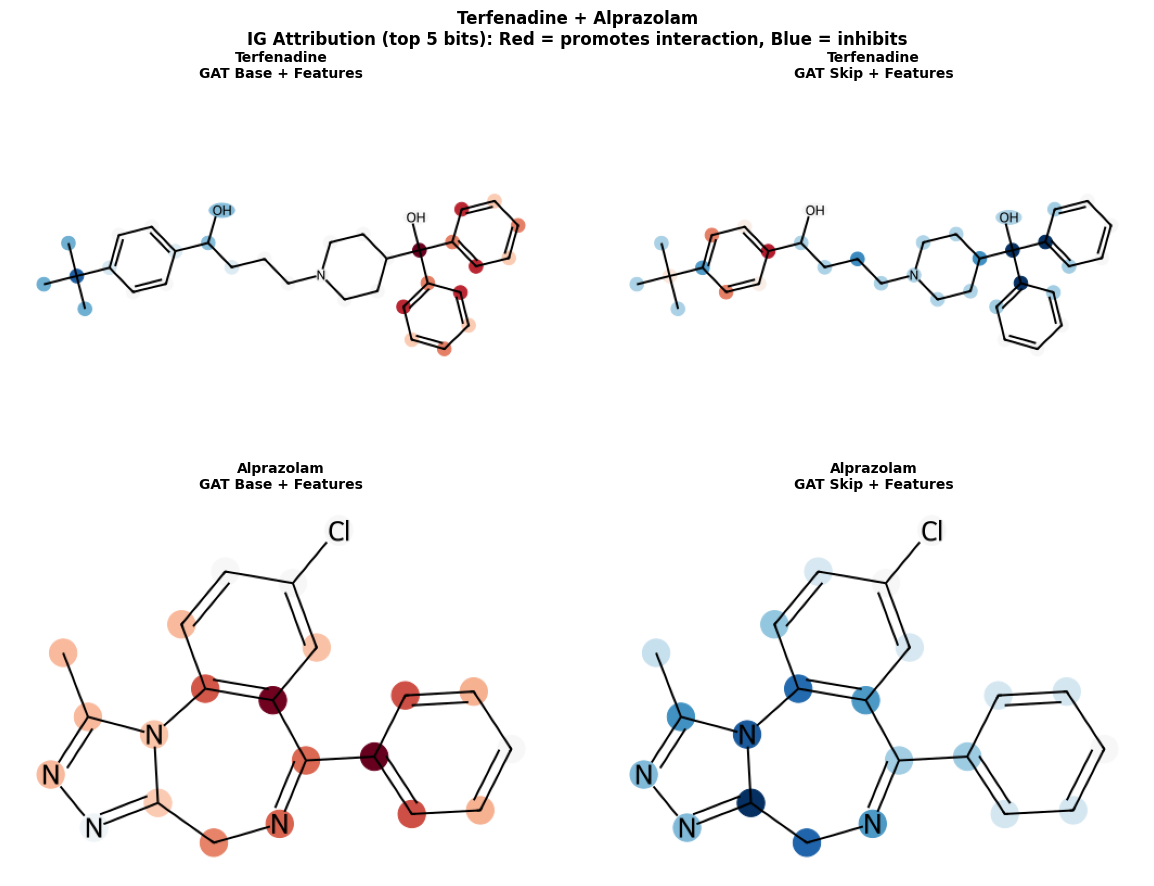


Terfenadine + Alprazolam - Substructure Details (GAT Skip+Feat)

  Terfenadine:
    Bit 1665: IG=+0.1066 (promotes) -> Cc1ccccc1
    Bit 1417: IG=-0.0947 (inhibits) -> cc(C)c.cc(Cc(c)c)c
    Bit 1556: IG=-0.0885 (inhibits) -> ccc(C(C)(C)C)cc
    Bit 548: IG=-0.0872 (inhibits) -> CCCCN
    Bit 925: IG=-0.0830 (inhibits) -> cC(c)(O)C(CC)CC

  Alprazolam:
    Bit 470: IG=-0.1389 (inhibits) -> cc(c)-n1c(C)nnc1C
    Bit 982: IG=-0.1281 (inhibits) -> c-n1cnnc1CN
    Bit 1571: IG=-0.1094 (inhibits) -> cC(c(cc)cc)=N
    Bit 135: IG=-0.1082 (inhibits) -> cCN
    Bit 1710: IG=-0.1003 (inhibits) -> Cc(c)c(cc)-n(c)c


[03:32:35] DEPRECATION WARNING: please use MorganGenerator
[03:32:35] DEPRECATION WARNING: please use MorganGenerator
[03:32:35] DEPRECATION WARNING: please use MorganGenerator
[03:32:35] DEPRECATION WARNING: please use MorganGenerator
[03:32:35] DEPRECATION WARNING: please use MorganGenerator
[03:32:35] DEPRECATION WARNING: please use MorganGenerator


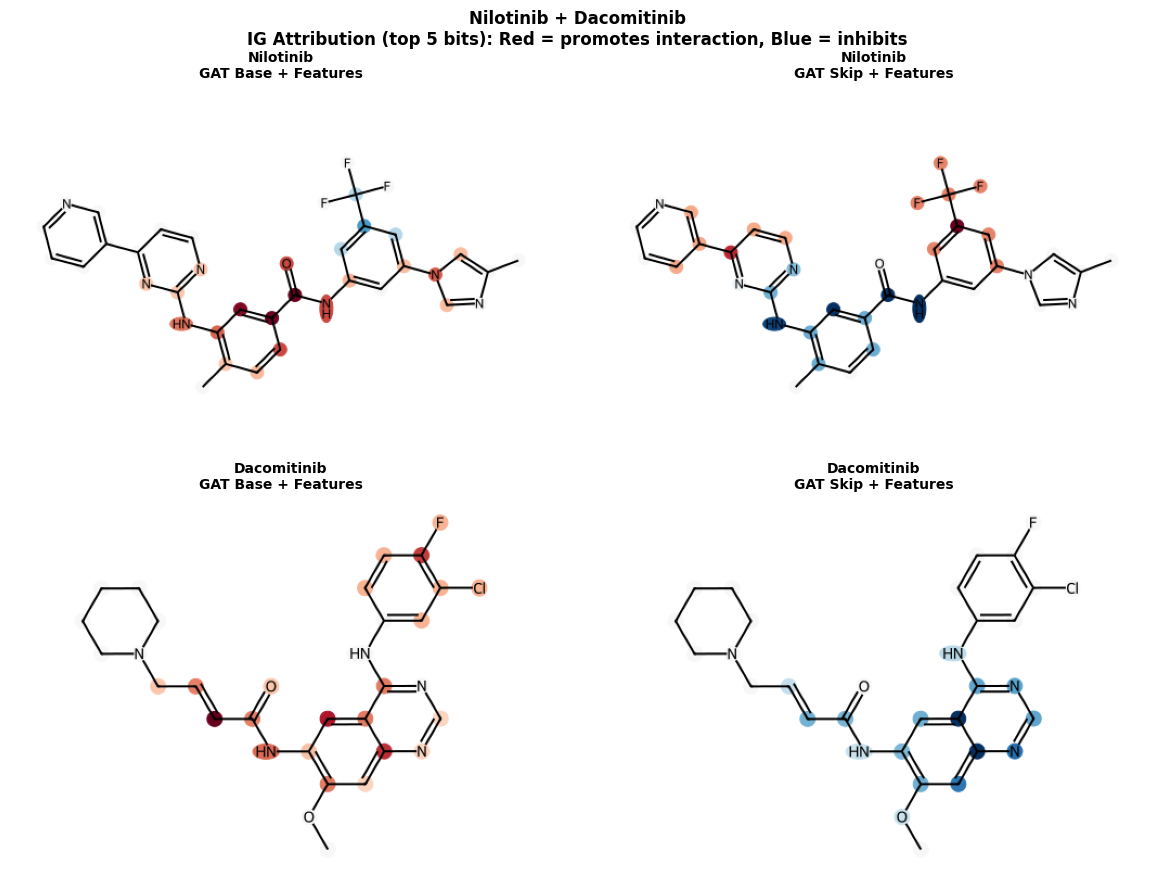


Nilotinib + Dacomitinib - Substructure Details (GAT Skip+Feat)

  Nilotinib:
    Bit 1816: IG=-0.2405 (inhibits) -> CNc
    Bit 510: IG=-0.2402 (inhibits) -> Cc(c)cc(N)c
    Bit 1158: IG=+0.2378 (promotes) -> ccc(C(F)(F)F)cc
    Bit 1582: IG=-0.2069 (inhibits) -> nc(N)n
    Bit 2036: IG=+0.1819 (promotes) -> ccc(-c(c)c)nc

  Dacomitinib:
    Bit 1367: IG=-0.2538 (inhibits) -> cc(N)ncn
    Bit 673: IG=-0.2452 (inhibits) -> ccc(nc)c(c)c
    Bit 31: IG=-0.2276 (inhibits) -> CC=C
    Bit 1097: IG=-0.2248 (inhibits) -> cc(c)n
    Bit 1058: IG=-0.2101 (inhibits) -> CNc(cc)c(O)c


[03:32:36] DEPRECATION WARNING: please use MorganGenerator
[03:32:36] DEPRECATION WARNING: please use MorganGenerator
[03:32:36] DEPRECATION WARNING: please use MorganGenerator
[03:32:36] DEPRECATION WARNING: please use MorganGenerator
[03:32:36] DEPRECATION WARNING: please use MorganGenerator
[03:32:36] DEPRECATION WARNING: please use MorganGenerator


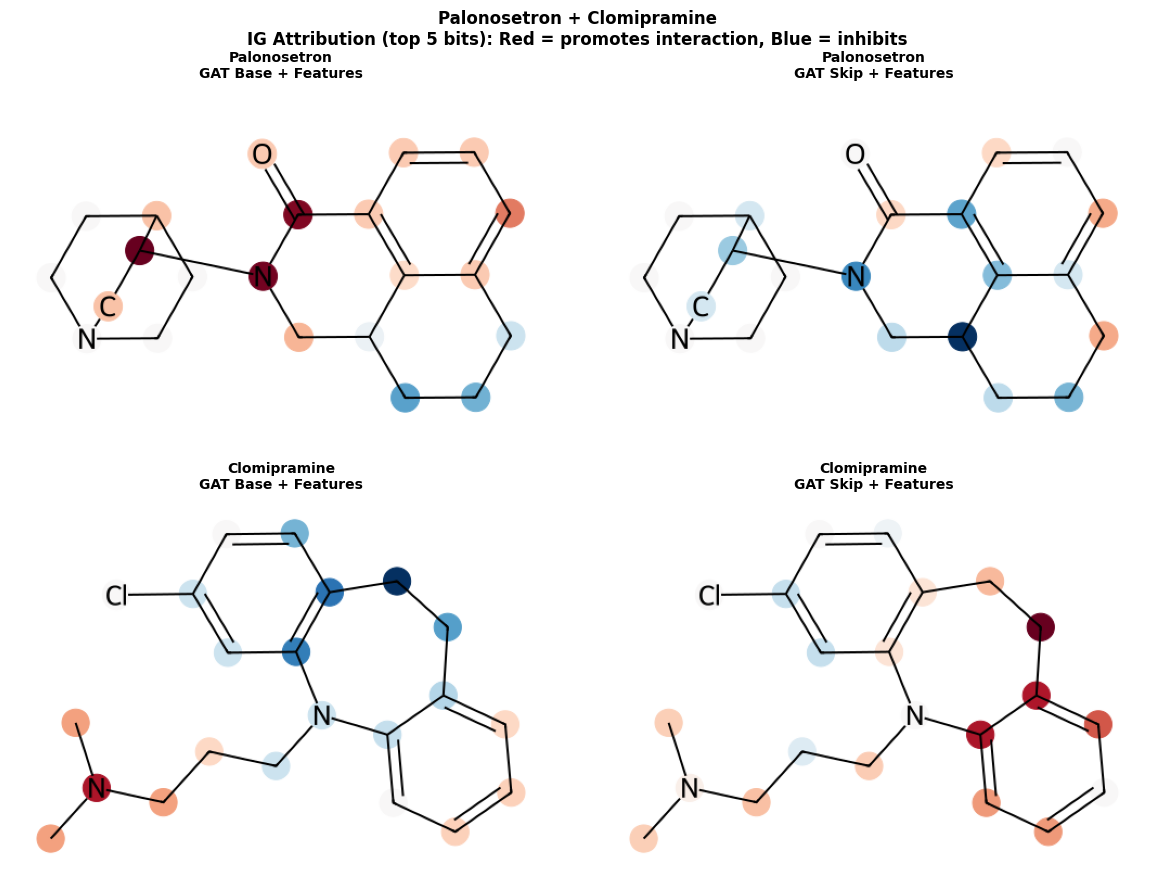


Palonosetron + Clomipramine - Substructure Details (GAT Skip+Feat)

  Palonosetron:
    Bit 1821: IG=-0.2344 (inhibits) -> cc(c)C(CC)CN
    Bit 1648: IG=-0.1384 (inhibits) -> cc(c)C
    Bit 1197: IG=+0.1031 (promotes) -> Cc(c)c(c(c)C)C(C)C
    Bit 1689: IG=-0.0938 (inhibits) -> CC(N)C
    Bit 1236: IG=+0.0878 (promotes) -> cc(c)C

  Clomipramine:
    Bit 1211: IG=+0.2063 (promotes) -> cN(C)c(cc)c(c)C
    Bit 946: IG=+0.1169 (promotes) -> CCCN(C)C
    Bit 597: IG=-0.1135 (inhibits) -> cN(C)c(cc)c(c)C
    Bit 955: IG=-0.0902 (inhibits) -> NCCCN
    Bit 1665: IG=+0.0897 (promotes) -> cc(c)CCc(c)c


[03:32:37] DEPRECATION WARNING: please use MorganGenerator
[03:32:37] DEPRECATION WARNING: please use MorganGenerator
[03:32:37] DEPRECATION WARNING: please use MorganGenerator
[03:32:37] DEPRECATION WARNING: please use MorganGenerator
[03:32:37] DEPRECATION WARNING: please use MorganGenerator
[03:32:37] DEPRECATION WARNING: please use MorganGenerator


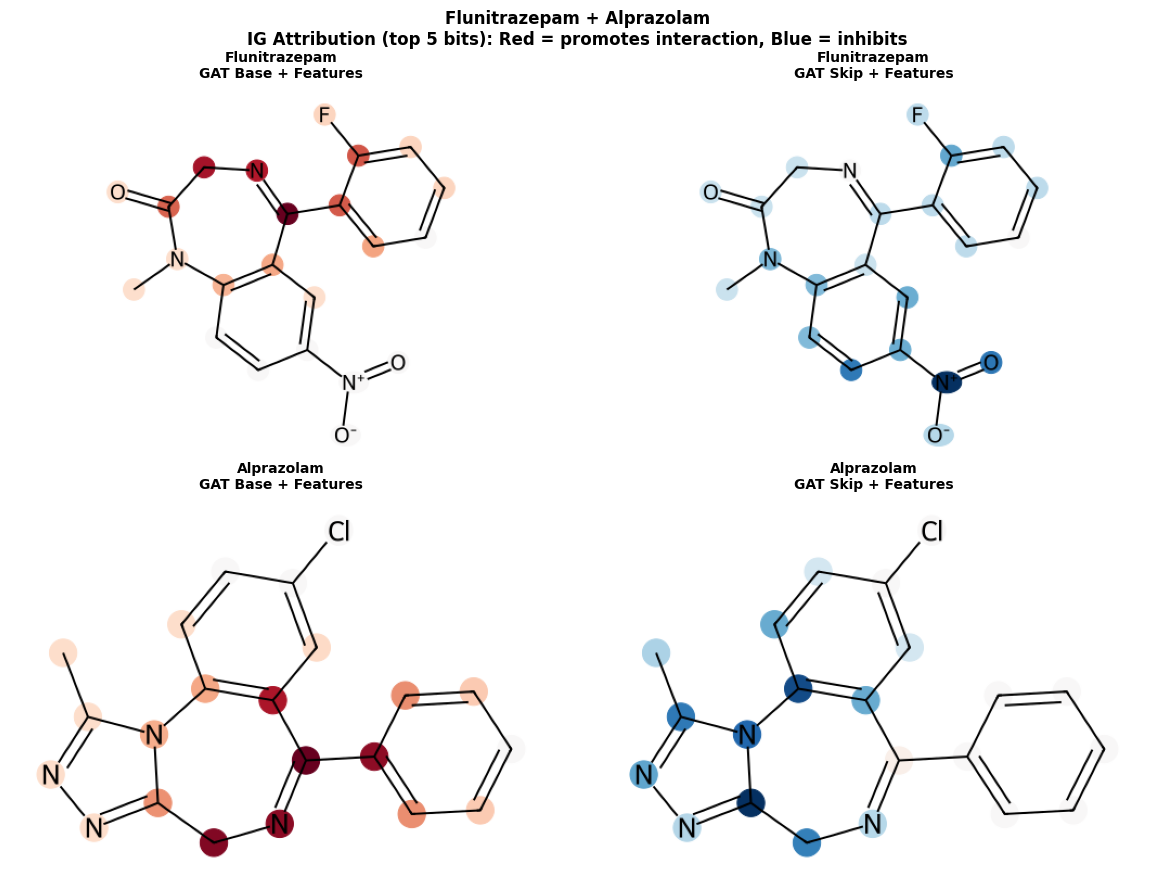


Flunitrazepam + Alprazolam - Substructure Details (GAT Skip+Feat)

  Flunitrazepam:
    Bit 1809: IG=-0.0856 (inhibits) -> cc([N+](=O)[O-])c
    Bit 451: IG=-0.0789 (inhibits) -> Cc(c)c(F)cc
    Bit 1074: IG=-0.0682 (inhibits) -> cc(c)N(C)C(=O)C
    Bit 753: IG=-0.0666 (inhibits) -> [N+]=O
    Bit 1814: IG=-0.0659 (inhibits) -> cccc([N+])c

  Alprazolam:
    Bit 470: IG=-0.1047 (inhibits) -> cc(c)-n1c(C)nnc1C
    Bit 135: IG=-0.1036 (inhibits) -> cCN
    Bit 871: IG=+0.0788 (promotes) -> C=NCc(n)n
    Bit 982: IG=-0.0697 (inhibits) -> c-n1cnnc1CN
    Bit 1710: IG=-0.0601 (inhibits) -> Cc(c)c(cc)-n(c)c


[03:32:38] DEPRECATION WARNING: please use MorganGenerator
[03:32:38] DEPRECATION WARNING: please use MorganGenerator
[03:32:38] DEPRECATION WARNING: please use MorganGenerator
[03:32:38] DEPRECATION WARNING: please use MorganGenerator
[03:32:38] DEPRECATION WARNING: please use MorganGenerator
[03:32:38] DEPRECATION WARNING: please use MorganGenerator


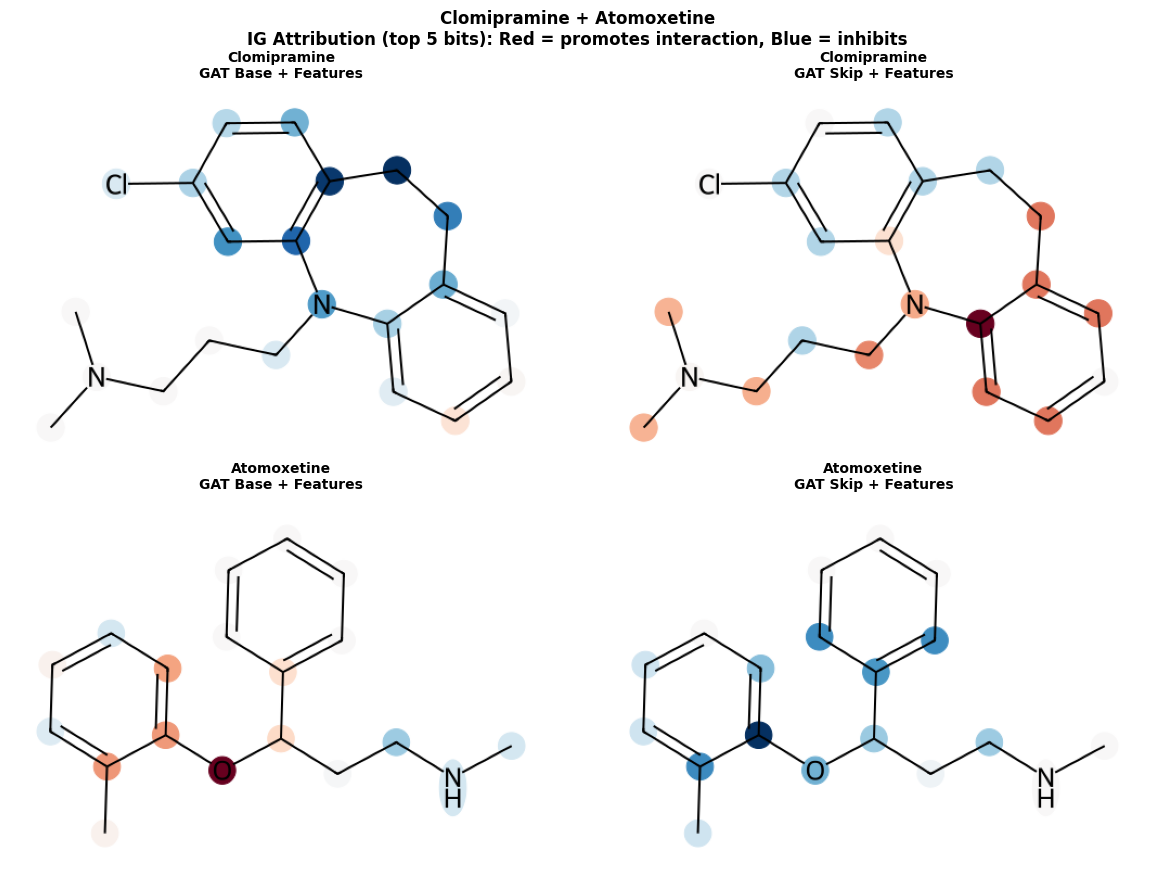


Clomipramine + Atomoxetine - Substructure Details (GAT Skip+Feat)

  Clomipramine:
    Bit 1211: IG=+0.1985 (promotes) -> cN(C)c(cc)c(c)C
    Bit 946: IG=+0.1289 (promotes) -> CCCN(C)C
    Bit 955: IG=-0.1213 (inhibits) -> NCCCN
    Bit 597: IG=-0.1133 (inhibits) -> cN(C)c(cc)c(c)C
    Bit 588: IG=+0.0890 (promotes) -> cN(C)c

  Atomoxetine:
    Bit 538: IG=-0.0949 (inhibits) -> cOC(CC)c(c)c
    Bit 1761: IG=+0.0810 (promotes) -> cC(C)O
    Bit 1365: IG=-0.0692 (inhibits) -> cc(C)c
    Bit 1970: IG=-0.0560 (inhibits) -> cc(O)c
    Bit 948: IG=-0.0549 (inhibits) -> ccc(C)c(O)c

All visualizations saved to /content/drive/MyDrive/ddi_capstone/GAT_ablation_h128/visualizations/


[03:32:39] DEPRECATION WARNING: please use MorganGenerator
[03:32:39] DEPRECATION WARNING: please use MorganGenerator


In [ ]:
# -- Map Morgan Fingerprint Bits to Molecular Substructures --
# Visualize which parts of each molecule receive the most attribution
# from Integrated Gradients, comparing GAT Base+Feat vs GAT Skip+Feat.
# Color gradient: Red = strong positive IG (promotes interaction),
# Blue = strong negative IG (inhibits interaction). Intensity proportional
# to absolute IG value.

from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from io import BytesIO
from PIL import Image
import pandas as pd


def get_atom_attributions(smiles, ig_values, bit_indices, radius=2):
    """Map IG bit attributions to per-atom scores. Each atom gets the
    sum of IG values from all bits it participates in."""
    if pd.isna(smiles) or smiles == '':
        return None, None

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None

    bit_info = {}
    AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=2048, bitInfo=bit_info)

    atom_scores = np.zeros(mol.GetNumAtoms())

    for bit, ig_val in zip(bit_indices, ig_values):
        if bit in bit_info:
            for center, rad in bit_info[bit]:
                env = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, center)
                atom_map = {}
                Chem.PathToSubmol(mol, env, atomMap=atom_map)
                for atom_idx in atom_map.keys():
                    atom_scores[atom_idx] += ig_val
                atom_scores[center] += ig_val

    return mol, atom_scores


def draw_molecule_attribution(mol, atom_scores, title, ax):
    """Draw molecule with red-blue gradient based on atom attribution scores."""
    if mol is None:
        ax.text(0.5, 0.5, 'No SMILES', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return

    # Normalize scores symmetrically around 0
    max_abs = max(np.abs(atom_scores).max(), 1e-8)
    norm = Normalize(vmin=-max_abs, vmax=max_abs)
    cmap = plt.cm.RdBu_r  # Red = positive, Blue = negative

    highlight_atoms = list(range(len(atom_scores)))
    atom_colors = {}
    for i, score in enumerate(atom_scores):
        rgba = cmap(norm(score))
        atom_colors[i] = (rgba[0], rgba[1], rgba[2])

    # Draw to PNG via RDKit
    drawer = rdMolDraw2D.MolDraw2DCairo(500, 350)
    drawer.drawOptions().addAtomIndices = False
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=atom_colors,
        highlightBonds=[]
    )
    drawer.FinishDrawing()

    img = Image.open(BytesIO(drawer.GetDrawingText()))
    ax.imshow(img)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')


# Generate comparison plots for all 5 pairs: GAT Base+Feat vs GAT Skip+Feat
# Using top 5 bits for focused, interpretable coloring

for pair in selected_pairs:
    pair_name = pair['name']
    drug_a_name = idx_to_name.get(pair['a'], f"Drug_{pair['a']}")
    drug_b_name = idx_to_name.get(pair['b'], f"Drug_{pair['b']}")
    smiles_a = idx_to_smiles.get(pair['a'], '')
    smiles_b = idx_to_smiles.get(pair['b'], '')

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(f'{pair_name}\nIG Attribution (top 5 bits): Red = promotes interaction, Blue = inhibits',
                 fontsize=12, fontweight='bold')

    for col, (model_name, model_label) in enumerate([
        ('GAT_base_feat', 'GAT Base + Features'),
        ('GAT_skip_feat', 'GAT Skip + Features')
    ]):
        ig_data = ig_results[pair_name][model_name]

        # Drug A — top 5 bits
        bits_a = ig_data['drug_a_top_bits'][:5]
        vals_a = ig_data['drug_a_top_values'][:5]
        mol_a, scores_a = get_atom_attributions(smiles_a, vals_a, bits_a)
        draw_molecule_attribution(mol_a, scores_a, f'{drug_a_name}\n{model_label}', axes[0, col])

        # Drug B — top 5 bits
        bits_b = ig_data['drug_b_top_bits'][:5]
        vals_b = ig_data['drug_b_top_values'][:5]
        mol_b, scores_b = get_atom_attributions(smiles_b, vals_b, bits_b)
        draw_molecule_attribution(mol_b, scores_b, f'{drug_b_name}\n{model_label}', axes[1, col])

    plt.tight_layout()
    safe_name = pair_name.replace(' + ', '_').replace(' ', '_')
    plt.savefig(f'{save_dir}/visualizations/ig_comparison_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print substructure details for GAT Skip+Feat
    print(f"\n{'='*60}")
    print(f"{pair_name} - Substructure Details (GAT Skip+Feat)")
    print(f"{'='*60}")

    ig_skip = ig_results[pair_name]['GAT_skip_feat']

    subs_a = get_bit_substructures(smiles_a, ig_skip['drug_a_top_bits'][:5])
    print(f"\n  {drug_a_name}:")
    for bit, val in zip(ig_skip['drug_a_top_bits'][:5], ig_skip['drug_a_top_values'][:5]):
        sub = subs_a.get(bit, {})
        smarts = sub.get('smarts', 'bit not active in molecule')
        direction = 'promotes' if val > 0 else 'inhibits'
        print(f"    Bit {bit}: IG={val:+.4f} ({direction}) -> {smarts}")

    subs_b = get_bit_substructures(smiles_b, ig_skip['drug_b_top_bits'][:5])
    print(f"\n  {drug_b_name}:")
    for bit, val in zip(ig_skip['drug_b_top_bits'][:5], ig_skip['drug_b_top_values'][:5]):
        sub = subs_b.get(bit, {})
        smarts = sub.get('smarts', 'bit not active in molecule')
        direction = 'promotes' if val > 0 else 'inhibits'
        print(f"    Bit {bit}: IG={val:+.4f} ({direction}) -> {smarts}")

print(f"\nAll visualizations saved to {save_dir}/visualizations/")

In [ ]:
# -- ExAI Final Summary and Save --
# Comprehensive summary of all explainability analyses for documentation.

# Save perturbation results (simplified for JSON)
pert_save = {}
for pair_name in perturbation_results:
    pert_save[pair_name] = {}
    for model_name in perturbation_results[pair_name]:
        pert_save[pair_name][model_name] = [
            {k: v for k, v in r.items() if k != 'neighbor_cyp'}
            for r in perturbation_results[pair_name][model_name][:20]
        ]

with open(f'{save_dir}/results/perturbation_results.json', 'w') as f:
    json.dump(pert_save, f, indent=2)

# Save IG results (without numpy arrays)
ig_save = {}
for pair_name in ig_results:
    ig_save[pair_name] = {}
    for model_name in ig_results[pair_name]:
        ig_save[pair_name][model_name] = {
            'drug_a_top_bits': ig_results[pair_name][model_name]['drug_a_top_bits'],
            'drug_b_top_bits': ig_results[pair_name][model_name]['drug_b_top_bits'],
            'drug_a_top_values': ig_results[pair_name][model_name]['drug_a_top_values'],
            'drug_b_top_values': ig_results[pair_name][model_name]['drug_b_top_values'],
        }

with open(f'{save_dir}/results/ig_results.json', 'w') as f:
    json.dump(ig_save, f, indent=2)

# Save concordance
with open(f'{save_dir}/results/concordance_results.json', 'w') as f:
    json.dump(concordance_results, f, indent=2, default=str)

print("All ExAI results saved to Drive")
print(f"\nFiles in {save_dir}/results/:")
for f in os.listdir(f'{save_dir}/results/'):
    print(f"  {f}")

print(f"\nFiles in {save_dir}/visualizations/:")
for f in os.listdir(f'{save_dir}/visualizations/'):
    print(f"  {f}")

All ExAI results saved to Drive

Files in /content/drive/MyDrive/ddi_capstone/GAT_ablation_h128/results/:
  gat_base_history.json
  gat_base_test_results.json
  gat_skip_history.json
  gat_skip_test_results.json
  gat_base_feat_history.json
  gat_base_feat_test_results.json
  gat_skip_feat_history.json
  gat_skip_feat_test_results.json
  exai_results.json
  perturbation_results.json
  ig_results.json
  concordance_results.json

Files in /content/drive/MyDrive/ddi_capstone/GAT_ablation_h128/visualizations/:
  gat_base_training_curves.png
  gat_skip_training_curves.png
  gat_base_feat_training_curves.png
  gat_skip_feat_training_curves.png
  ig_comparison_Terfenadine_Alprazolam.png
  ig_comparison_Nilotinib_Dacomitinib.png
  ig_comparison_Palonosetron_Clomipramine.png
  ig_comparison_Flunitrazepam_Alprazolam.png
  ig_comparison_Clomipramine_Atomoxetine.png


## Biological validation

In [ ]:
# ============================================================================
# Biological Validation — All Four GAT Variants
# ============================================================================
# For each GAT model, takes the top-5000 highest-scoring test pairs and
# compares their biological overlap against 5000 random drug pairs using
# Fisher's exact test (one-sided, alternative='greater').
#
# top_k=5000 used for GAT (same as GraphSAGE) because GAT score distributions
# are also compressed, yielding insufficient annotated pairs at top-200.
# Same methodology and baseline across all architectures enables
# fair cross-model comparison of biological interpretability.
#
# Functions redefined here so this section runs independently.

from scipy.stats import fisher_exact
from collections import defaultdict

drugbank_path = '/content/drive/MyDrive/ddi_capstone/full_drugbank_parsing'

try:
    df_enz = pd.read_csv(os.path.join(drugbank_path, 'ogb_drug_enzymes.csv'))
    df_tgt = pd.read_csv(os.path.join(drugbank_path, 'ogb_drug_targets.csv'))
    df_trn = pd.read_csv(os.path.join(drugbank_path, 'ogb_drug_transporters.csv'))
except FileNotFoundError as e:
    raise FileNotFoundError(
        f"DrugBank annotation file not found: {e}. "
        "Ensure full_drugbank_parsing/ is present in Drive."
    )


def build_lookup(df, entity_col, idx_col='ogb_idx'):
    """Build OGB index -> set of entity names from a long-format DataFrame."""
    lookup = defaultdict(set)
    for _, row in df.iterrows():
        idx = int(row[idx_col])
        entity = row[entity_col]
        if pd.notna(entity):
            lookup[idx].add(entity)
    return dict(lookup)


enzyme_lookup      = build_lookup(df_enz, 'enzyme_name')
target_lookup      = build_lookup(df_tgt, 'target_name')
transporter_lookup = build_lookup(df_trn, 'transporter_name')


def compute_biological_overlap(pairs, lookup):
    """Count pairs where both drugs share at least one biological entity.
    Only counts pairs where both drugs have annotations (avoids denominator bias)."""
    n_overlap, n_annotated = 0, 0
    details = []
    for idx_a, idx_b in pairs:
        set_a = lookup.get(idx_a, set())
        set_b = lookup.get(idx_b, set())
        if set_a and set_b:
            n_annotated += 1
            shared = set_a & set_b
            if shared:
                n_overlap += 1
                details.append((idx_a, idx_b, shared))
    rate = n_overlap / n_annotated if n_annotated > 0 else 0
    return n_overlap, n_annotated, rate, details


def biological_validation(predicted_pairs, random_pairs, lookup, entity_name):
    """One-sided Fisher's exact test: predicted pairs vs random baseline.

    H0: predicted pairs share biology at the same rate as random.
    H1: predicted pairs share MORE biology than random (alternative='greater').
    OR > 1 and p < 0.05 → model captures real biological mechanisms.
    """
    pred_overlap, pred_ann, pred_rate, pred_details = compute_biological_overlap(
        predicted_pairs, lookup
    )
    rand_overlap, rand_ann, rand_rate, rand_details = compute_biological_overlap(
        random_pairs, lookup
    )
    a, b = pred_overlap, pred_ann - pred_overlap
    c, d = rand_overlap, rand_ann - rand_overlap

    if pred_ann > 0 and rand_ann > 0:
        odds_ratio, p_value = fisher_exact([[a, b], [c, d]], alternative='greater')
    else:
        odds_ratio, p_value = float('nan'), float('nan')

    return {
        'entity_type': entity_name,
        'pred_overlap': pred_overlap, 'pred_annotated': pred_ann, 'pred_rate': pred_rate,
        'rand_overlap': rand_overlap, 'rand_annotated': rand_ann, 'rand_rate': rand_rate,
        'odds_ratio': odds_ratio, 'p_value': p_value,
    }


def generate_random_pairs(n_pairs, num_nodes, seed=42):
    """Generate undirected random drug pairs as biological validation baseline."""
    rng = np.random.RandomState(seed)
    pairs = set()
    while len(pairs) < n_pairs:
        a, b = rng.randint(0, num_nodes, size=2)
        if a != b:
            pairs.add((min(a, b), max(a, b)))
    return list(pairs)


# Shared random baseline across all four GAT variants
top_k = 5000
random_pairs = generate_random_pairs(top_k, num_nodes, seed=42)

all_validation = {}

for model_name, (model, x) in models_dict.items():
    pred = pred_map[model_name]
    model.eval()
    pred.eval()

    try:
        with torch.no_grad():
            emb = model.encode(x, edge_index)
            test_pos_scores = torch.sigmoid(
                pred(emb[test_pos[:, 0]], emb[test_pos[:, 1]])
            ).cpu().numpy().flatten()
    except RuntimeError as e:
        print(f"Scoring failed for {model_name}: {e}")
        continue

    top_indices = np.argsort(test_pos_scores)[-top_k:]
    top_pairs = [(int(test_pos[i, 0]), int(test_pos[i, 1])) for i in top_indices]

    print(f"\n{'='*75}")
    print(f"BIOLOGICAL VALIDATION — {model_name} "
          f"(top {top_k} test pairs vs random)")
    print(f"Score range: {test_pos_scores[top_indices[0]]:.4f} – "
          f"{test_pos_scores[top_indices[-1]]:.4f}")
    print(f"{'='*75}")
    print(f"{'Entity':<15} | {'Predicted':>18} | {'Random':>18} | {'OR':>6} | {'p-value':>8}")
    print("-" * 75)

    all_validation[model_name] = {}
    for lookup, name in [
        (enzyme_lookup,      'Enzymes'),
        (target_lookup,      'Targets'),
        (transporter_lookup, 'Transporters'),
    ]:
        r = biological_validation(top_pairs, random_pairs, lookup, name)
        all_validation[model_name][name] = r

        pred_str = f"{r['pred_overlap']}/{r['pred_annotated']} ({r['pred_rate']:.1%})"
        rand_str = f"{r['rand_overlap']}/{r['rand_annotated']} ({r['rand_rate']:.1%})"
        or_str   = f"{r['odds_ratio']:.2f}" if not np.isnan(r['odds_ratio']) else "N/A"
        p_str    = f"{r['p_value']:.4f}"    if not np.isnan(r['p_value'])    else "N/A"
        sig = ('***' if r['p_value'] < 0.001 else
               '**'  if r['p_value'] < 0.01  else
               '*'   if r['p_value'] < 0.05  else '')
        print(f"{name:<15} | {pred_str:>18} | {rand_str:>18} | "
              f"{or_str:>6} | {p_str:>8} {sig}")

# Persist results — convert nan to None for valid JSON serialization
val_save = {}
for model_name in all_validation:
    val_save[model_name] = {}
    for entity, r in all_validation[model_name].items():
        val_save[model_name][entity] = {
            k: v for k, v in r.items() if k != 'pred_details'
        }
        val_save[model_name][entity]['odds_ratio'] = (
            None if np.isnan(r['odds_ratio']) else float(r['odds_ratio'])
        )
        val_save[model_name][entity]['p_value'] = (
            None if np.isnan(r['p_value']) else float(r['p_value'])
        )

try:
    with open(f'{save_dir}/results/biological_validation.json', 'w') as f:
        json.dump(val_save, f, indent=2)
    print(f"\nResults saved to {save_dir}/results/biological_validation.json")
except OSError as e:
    print(f"Warning: could not save results — {e}")

print(f"\nFisher's exact test (one-sided, greater)")
print(f"p < 0.05 = predicted pairs share significantly more biology than random")


BIOLOGICAL VALIDATION - GAT_base (top 5000 test pairs vs random)
Score range: 0.8531 - 0.8575
Entity          |          Predicted |             Random |     OR |  p-value
---------------------------------------------------------------------------
Enzymes         |   376/1017 (37.0%) |    343/756 (45.4%) |   0.71 |   0.9998
Targets         |    335/4974 (6.7%) |     53/2590 (2.0%) |   3.46 |   0.0000
Transporters    |    117/445 (26.3%) |    112/251 (44.6%) |   0.44 |   1.0000

BIOLOGICAL VALIDATION - GAT_skip (top 5000 test pairs vs random)
Score range: 0.8561 - 0.8812
Entity          |          Predicted |             Random |     OR |  p-value
---------------------------------------------------------------------------
Enzymes         |    340/876 (38.8%) |    343/756 (45.4%) |   0.76 |   0.9968
Targets         |    491/4977 (9.9%) |     53/2590 (2.0%) |   5.24 |   0.0000
Transporters    |     95/335 (28.4%) |    112/251 (44.6%) |   0.49 |   1.0000

BIOLOGICAL VALIDATION - GAT_base_

## Biological Validation Summary

Fisher's exact test (one-sided, greater) across all model architectures. Predicted pairs from top-ranked test predictions vs. random baseline. p < 0.05 indicates predicted pairs share significantly more biological entities than random.

## Cross-Architecture Results

| Model | Enzymes (OR, p) | Targets (OR, p) | Transporters (OR, p) |
|-------|-----------------|-----------------|---------------------|
| MLP (top 200) | **OR=4.84, p=0.0016** | OR=1.52, p=0.34 | OR=1.93, p=0.38 |
| GraphSAGE No Feat (top 5000) | OR=0.40, p=1.00 | **OR=2.84, p<0.0001** | OR=0.35, p=1.00 |
| GraphSAGE With Feat (top 5000) | OR=0.54, p=0.99 | **OR=4.16, p<0.0001** | OR=0.39, p=0.99 |
| GAT Base (top 5000) | OR=0.71, p=0.99 | **OR=3.46, p<0.0001** | OR=0.44, p=1.00 |
| GAT Skip (top 5000) | OR=0.76, p=0.99 | **OR=5.24, p<0.0001** | OR=0.49, p=1.00 |
| GAT Base+Feat (top 5000) | OR=0.86, p=0.95 | **OR=3.46, p<0.0001** | OR=0.21, p=1.00 |
| GAT Skip+Feat (top 5000) | OR=0.45, p=1.00 | **OR=4.04, p<0.0001** | OR=0.35, p=1.00 |

## Key Findings

1. **MLP captures pharmacokinetic (enzyme-mediated) interactions.** The MLP baseline shows significant enrichment in shared CYP enzymes (OR=4.84, p=0.0016) but no signal for targets or transporters. Operating directly on Morgan fingerprints, the MLP learns that molecular substructure similarity predicts metabolic pathway overlap.

2. **All graph-based models capture pharmacodynamic (target-mediated) interactions.** Every GraphSAGE and GAT variant shows highly significant target enrichment (p<0.0001). None capture enzyme overlap. Graph topology encodes which drugs act on the same biological targets, independent of molecular structure.

3. **Molecular features strengthen the target signal in both architectures.** GraphSAGE With Features (OR=4.16) outperforms No Features (OR=2.84). Similarly, GAT Skip (OR=5.24) outperforms GAT Base (OR=3.46). Adding structural information to graph topology helps the model better identify target-sharing drug pairs.

4. **GAT Skip achieves the strongest target enrichment overall (OR=5.24).** The combination of attention-based message passing and skip connections produces the most pharmacodynamically informative predictions across all architectures.

5. **The two mechanisms are complementary, not redundant.** MLP finds enzyme signal but not target signal. All graph models find target signal but not enzyme signal. This is the core finding of the explainability ladder: each architecture captures a biologically distinct interaction mechanism. A combined system would provide more complete pharmacological understanding than any single model.

6. **No model captures transporter-mediated interactions.** This likely reflects sparse transporter annotations in DrugBank rather than a model limitation.

In [ ]:
for pair in selected_pairs:
    name = pair['name']
    print(f"\n{name}:")
    for model_name, (model, x) in models_dict.items():
        pred = pred_map[model_name]
        model.eval()
        pred.eval()
        with torch.no_grad():
            if x is not None:
                emb = model.encode(x, edge_index)
            else:
                emb = model.encode(None, edge_index)
            score = torch.sigmoid(pred(emb[pair['a']].unsqueeze(0), emb[pair['b']].unsqueeze(0))).item()
        print(f"  {model_name}: {score:.1%}")


Terfenadine + Alprazolam:
  GAT_base: 84.6%
  GAT_skip: 84.7%
  GAT_base_feat: 81.2%
  GAT_skip_feat: 85.3%

Nilotinib + Dacomitinib:
  GAT_base: 81.3%
  GAT_skip: 82.7%
  GAT_base_feat: 77.9%
  GAT_skip_feat: 84.9%

Palonosetron + Clomipramine:
  GAT_base: 85.1%
  GAT_skip: 84.7%
  GAT_base_feat: 84.0%
  GAT_skip_feat: 85.6%

Flunitrazepam + Alprazolam:
  GAT_base: 85.1%
  GAT_skip: 84.8%
  GAT_base_feat: 82.5%
  GAT_skip_feat: 85.4%

Clomipramine + Atomoxetine:
  GAT_base: 85.0%
  GAT_skip: 85.2%
  GAT_base_feat: 83.8%
  GAT_skip_feat: 85.4%


### ExAI Case Studies (5 pairs from top MLP predictions)

| Drug Pair | Shared Enzymes | Shared Targets |
|-----------|---------------|----------------|
| Terfenadine + Alprazolam | CYP3A4, CYP3A5, CYP3A7 | — |
| Nilotinib + Dacomitinib | CYP2C9, CYP2D6, CYP3A4 | — |
| Palonosetron + Clomipramine | CYP1A2, CYP2D6, CYP3A4 | — |
| Flunitrazepam + Alprazolam | CYP2C9, CYP3A4 | GABA(A) Receptor, Translocator protein |
| Clomipramine + Atomoxetine | CYP2C19, CYP2D6 | Noradrenaline transporter, Serotonin transporter |

# Biological Validation: Fisher's Exact Test

**Configuration:** Top 5,000 highest-scoring test pairs vs 5,000 random pairs | One-sided Fisher's exact test (greater) | Full DrugBank XML annotations

## Results

| Model | Enzymes Rate (OR) | p-value | Targets Rate (OR) | p-value | Transporters Rate (OR) | p-value |
|-------|-------------------|---------|-------------------|---------|------------------------|---------|
| GAT Base | 37.0% (0.71) | 1.000 | **6.7% (3.46)** | **<0.001** | 26.3% (0.44) | 1.000 |
| GAT Skip | 38.8% (0.76) | 0.997 | **9.9% (5.24)** | **<0.001** | 28.4% (0.49) | 1.000 |
| GAT Base+Feat | 41.6% (0.86) | 0.947 | **6.7% (3.46)** | **<0.001** | 14.7% (0.21) | 1.000 |
| GAT Skip+Feat | 27.2% (0.45) | 1.000 | **7.8% (4.04)** | **<0.001** | 21.9% (0.35) | 1.000 |
| GraphSAGE Topo | 25.0% (0.40) | 1.000 | **5.6% (2.84)** | **<0.001** | 22.0% (0.35) | 1.000 |
| GraphSAGE Feat | 31.1% (0.54) | 0.999 | **8.0% (4.16)** | **<0.001** | 24.1% (0.39) | 1.000 |
| MLP (reference) | **69.5% (4.84)** | **0.002** | 6.0% (1.52) | 0.341 | 72.0% (1.93) | 0.376 |
| Random baseline | 45.4% | — | 2.0% | — | 44.6% | — |

Note: MLP validation used top-200 pairs (sufficient annotation coverage due to direct fingerprint-based scoring). All GNN models used top-5,000 because their compressed score distributions (ranges 0.83–0.89) yield insufficient enzyme-annotated pairs at smaller K values.

## Key Findings

1. **All GNN models capture target-mediated DDIs (p<0.001).** Every graph-based model — regardless of architecture (GAT vs GraphSAGE) or feature configuration — shows highly significant enrichment for shared pharmacological targets. This confirms that graph topology encodes pharmacodynamic relationships between drugs.

2. **GAT Skip achieves the strongest target enrichment (OR=5.24).** Attention mechanisms with skip connections capture the most fine-grained target-level relationships, outperforming all other GNN variants. Skip connections likely improve gradient flow to the attention weights, enabling more precise neighbor weighting.

3. **MLP is the only model capturing enzyme-mediated DDIs (OR=4.84, p=0.002).** Operating directly on Morgan fingerprints, the MLP encodes molecular structure correlated with CYP enzyme binding sites — the primary mechanism of pharmacokinetic DDIs. GNN models dilute this direct structural signal through message passing.

4. **GNNs and MLP capture complementary biological mechanisms.** MLP captures pharmacokinetic interactions (shared CYP enzymes), while GNNs capture pharmacodynamic interactions (shared targets). This is a key finding supporting multi-model approaches: no single architecture captures all DDI mechanisms.

5. **No model captures transporter-mediated interactions.** All models show OR < 1 for transporters. This is likely due to sparse transporter annotations (966/4,267 drugs) and the lower prevalence of transporter-mediated DDIs compared to enzyme or target pathways.

6. **Molecular features do not consistently improve biological validation in GNNs.** Among GAT variants, GAT Base+Feat (OR=3.46) does not outperform topology-only GAT Skip (OR=5.24) for targets. Among GraphSAGE, features help (OR=4.16 vs 2.84). The benefit of features appears architecture-dependent.

# Explainability Analysis — GAT Models (h=128, heads=4) for DDI Prediction

## Methods Applied

| Method | Models | What It Measures |
|--------|--------|-----------------|
| Attention Weight Extraction | All 4 GAT | Which neighbors the model attends to (built-in) |
| Perturbation Analysis | All 4 GAT | Which neighbors most affect the prediction (post-hoc) |
| Integrated Gradients | GAT Base+Feat, GAT Skip+Feat | Which molecular substructures drive the prediction |

Analysis conducted on 5 drug pairs selected from top MLP predictions with known shared CYP enzymes, targets, and transporters from full DrugBank XML.

## Drug Pairs Analyzed

| Pair | Shared Enzymes | Shared Targets |
|------|---------------|----------------|
| Terfenadine + Alprazolam | CYP3A4, CYP3A5, CYP3A7 | — |
| Nilotinib + Dacomitinib | CYP2C9, CYP2D6, CYP3A4 | — |
| Palonosetron + Clomipramine | CYP1A2, CYP2D6, CYP3A4 | — |
| Flunitrazepam + Alprazolam | CYP2C9, CYP3A4 | GABA(A) Receptor, Translocator protein |
| Clomipramine + Atomoxetine | CYP2C19, CYP2D6 | NET, SERT |

## Key Findings

### 1. Attention Concentration Depends on Architecture

GAT Skip models concentrate attention 4-8x more than GAT Base (top alpha 0.12-0.20 vs 0.02-0.04). Feature-based models distribute attention most uniformly (top alpha 0.003-0.012). Skip connections allow selective attention by preserving information through residual paths; molecular features reduce the need for attention-based information gathering.

### 2. Attention and Perturbation Explanations Do Not Agree

Concordance between attention weights and perturbation impact is low across all models and pairs (average overlap 8.0% in top 20 neighbors). GAT Skip shows highest concordance (13.0%) while GAT Base+Feat shows lowest (4.0%). This confirms that attention weights should not be treated as faithful explanations — complementary methods are essential.

### 3. Skip Connections Enable 100x Stronger IG Attributions

GAT Skip+Feat produces IG values of 0.1-0.24 while GAT Base+Feat produces 0.0003-0.003. Skip connections improve gradient flow to fingerprint inputs, making molecular explanations more interpretable. Key substructures identified include trifluoromethyl groups (CYP3A4 substrates), triazole rings (benzodiazepine metabolism), and dimethylamino chains (CYP2D6 substrates).

### 4. Feature-based Models Identify CYP-relevant Perturbation Neighbors

GAT Base+Feat and Skip+Feat surface neighbors with CYP annotations in top perturbation targets. For Terfenadine+Alprazolam (shared CYP3A4/3A5/3A7), GAT Base+Feat identifies Clobetasol (CYP3A4/3A5) and Halometasone (CYP3A4/3A5) as top neighbors. Topology-only models show less biologically meaningful perturbation.

### 5. Biological Validation (Fisher's Exact Test, top-5000 pairs)

| Model | Enzymes (OR, p) | Targets (OR, p) | Transporters (OR, p) |
|-------|-----------------|-----------------|----------------------|
| GAT Base | 0.71, n.s. | **3.46, p<0.001** | 0.44, n.s. |
| GAT Skip | 0.76, n.s. | **5.24, p<0.001** | 0.49, n.s. |
| GAT Base+Feat | 0.86, n.s. | **3.46, p<0.001** | 0.21, n.s. |
| GAT Skip+Feat | 0.45, n.s. | **4.04, p<0.001** | 0.35, n.s. |
| Random baseline | 45.4% | 2.0% | 44.6% |

All four GAT variants show highly significant target enrichment (p<0.001). GAT Skip achieves the strongest effect (OR=5.24), suggesting attention with skip connections captures the most precise pharmacodynamic relationships. No GAT variant captures enzyme-mediated DDIs — this is uniquely captured by the MLP baseline (OR=4.84, p=0.002), confirming that graph topology and molecular features encode complementary biological mechanisms.

## Model Performance

| Model | Test AUC | F1 | Parameters |
|-------|----------|----|------------|
| GAT Base | 0.9556 | 0.9134 | ~300K |
| GAT Skip | 0.9743 | 0.9292 | ~300K |
| GAT Base+Feat | 0.9397 | ~TBD | ~300K |
| GAT Skip+Feat | 0.9871 | ~TBD | ~300K |

In [ ]:
import os, json

dirs = {
    'MLP': '/content/drive/MyDrive/ddi_capstone/MLP_baseline/models',
    'GraphSAGE': '/content/drive/MyDrive/ddi_capstone/graphsage',
    'GAT': '/content/drive/MyDrive/ddi_capstone/GAT_ablation_h128',
    'DrugBank': '/content/drive/MyDrive/ddi_capstone/full_drugbank_parsing',
    'Molecular': '/content/drive/MyDrive/ddi_capstone/molecular/data',
}

required_per_model = ['test_results', 'biological_validation', 'perturbation', 'ig_results']

for name, path in dirs.items():
    print(f"\n{'='*50}")
    print(f"{name}: {path}")
    print(f"{'='*50}")
    if os.path.exists(path):
        all_files = []
        for root, subdirs, files in os.walk(path):
            for f in sorted(files):
                rel = os.path.relpath(os.path.join(root, f), path)
                size = os.path.getsize(os.path.join(root, f))
                size_str = f"{size/1024:.0f}KB" if size < 1024*1024 else f"{size/1024/1024:.1f}MB"
                all_files.append((rel, size_str))
        for f, s in sorted(all_files):
            print(f"  {s:>8}  {f}")
    else:
        print("  NOT FOUND")


MLP: /content/drive/MyDrive/ddi_capstone/MLP_baseline/models
     1.1MB  best_model.pt
       1KB  biological_validation.json
       0KB  config.json
       6KB  ig_results.json
       0KB  test_results.json
       3KB  training_history.json

GraphSAGE: /content/drive/MyDrive/ddi_capstone/graphsage
     1.5MB  best_graphsage_feat.pt
     2.6MB  best_graphsage_topo.pt
       1KB  biological_validation.json
       1KB  config.json
       0KB  final_results.json
     1.3MB  grapshage.ipynb
      19KB  ig_results.json
     446KB  ig_substructures.png
     1.1MB  ig_substructures_mlp_pairs.png
     145KB  overfitting_check.png
      39KB  perturbation_results.json
       1KB  test_results.json
     269KB  training_curves_comparison.png

GAT: /content/drive/MyDrive/ddi_capstone/GAT_ablation_h128
       3KB  GAT_EXAI_SUMMARY.md
     2.6MB  models/gat_base_best.pt
     1.5MB  models/gat_base_feat_best.pt
     2.6MB  models/gat_skip_best.pt
     1.5MB  models/gat_skip_feat_best.pt
       4KB  